# SMBC 2025 コンペ

# ライブラリのインポート

In [1]:
%%bash
pip uninstall lightgbm --yes
pip install lightgbm \
    --no-binary lightgbm \
    --no-cache lightgbm \
    --config-settings=cmake.define.USE_CUDA=ON

pip install catboost -qq
pip install seaborn_qqplot -qq
pip install japanize-matplotlib optuna mojimoji optuna pymysql -qq
pip install optuna -qq
pip install optuna-integration -qq
pip install category_encoders -qq
pip install skorch -qq
pip install shirokumas -qq
pip install shap -qq
pip install jaconv -qq
pip install hydra-core -qq
pip install pyyaml -qq

Found existing installation: lightgbm 4.5.0
Uninstalling lightgbm-4.5.0:
  Successfully uninstalled lightgbm-4.5.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lightgbm: filename=lightgbm-4.6.0-py3-none-linux_x86_64.whl size=61750047 sha256=0a6605ae2b6d88ca8e27f25f62fa39d70abebeda3aab7b1ab546e609bf0c1246
  Stored in directory: /tmp/pip-ephem-wheel-cache-o380x3e6/wheels/ee/da/90/bd694ce19848ae41071e6c926d1650e4581556bf5869a57fe0
Successfully built lightgbm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/9

In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
import catboost
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
import functools
import datetime
from dateutil.parser import parse
import japanize_matplotlib
import optuna
import mojimoji as mjmj
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import category_encoders as ce
from pathlib import Path
import os
import re
import pickle
import math
from math import sqrt
from sklearn import preprocessing
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler ,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
import skorch
import torch
from torch import nn
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from skorch import NeuralNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
import jaconv
import unicodedata
import hydra
import sys
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from skorch import NeuralNetRegressor
from catboost import CatBoostRegressor
from omegaconf import OmegaConf, DictConfig
import yaml

# 生データのデータフレーム化

In [ ]:
"""
timeのUCTタイムスタンプ化=>.date

カテゴリ変数
　date, year, month, season, weather

ターゲットエンコード
　カテゴリ変数の数値化

標準化=>PCA=>クラスタリング
　dateでグルーピング、対象カラムの日の平均をとる。

集約特徴量
　カテゴリ変数のラベル単位で対象カラムの代表値をとる
　カラムが数値型なら平均値、文字列型なら最頻値

ラグ特徴量
　対象カラムのラグをとる。欠損値は平均値、最頻値で補完

移動平均

時間データの三角関数化

変化率

"""

'\ntimeのUCTタイムスタンプ化=>.date\n\nカテゴリ変数\n\u3000date, year, month, season, weather\n\nターゲットエンコード\n\u3000カテゴリ変数の数値化\n\n標準化=>PCA=>クラスタリング\n\u3000dateでグルーピング、対象カラムの日の平均をとる。\n\n集約特徴量\n\u3000カテゴリ変数のラベル単位で対象カラムの代表値をとる\n\u3000カラムが数値型なら平均値、文字列型なら最頻値\n\nラグ特徴量\n\u3000対象カラムのラグをとる。欠損値は平均値、最頻値で補完\n\n移動平均\n\n時間データの三角関数化\n\n変化率\n\n'

In [3]:
import pandas as pd
base_path = "/content/drive/MyDrive/signate/smbc"
row_tr_df = pd.read_csv(f"{base_path}/data/train.csv")
row_test_df = pd.read_csv(f"{base_path}/data/test.csv")
row_sample_df = pd.read_csv(f"{base_path}/data/sample_submit.csv", header=None)
row_feature_df = pd.read_csv(f"{base_path}/data/feature_description.csv", header=None)

In [ ]:
row_tr_df.isna().sum()[row_tr_df.isna().sum() > 0]

,0
generation_biomass,21
generation_fossil_brown_coal/lignite,20
generation_fossil_gas,20
generation_fossil_hard_coal,20
generation_fossil_oil,21
generation_hydro_pumped_storage_consumption,21
generation_hydro_run_of_river_and_poundage,21
generation_hydro_water_reservoir,20
generation_nuclear,19
generation_other,20


In [ ]:
row_test_df.isna().sum()[row_test_df.isna().sum() > 0]

,0
generation_biomass,2
generation_fossil_brown_coal/lignite,2
generation_fossil_gas,2
generation_fossil_hard_coal,2
generation_fossil_oil,2
generation_hydro_pumped_storage_consumption,2
generation_hydro_run_of_river_and_poundage,2
generation_hydro_water_reservoir,2
generation_nuclear,2
generation_other,2


# データの可視化

In [4]:
def get_binned_data(x, col, bins=10, label_format='{:02}_{:.0f}-{:.0f}'):

    # データ型チェック
    if type(x) not in (pd.Series, pd.DataFrame):
        x = pd.Series(x)

    if x.isnull().values.any():
        print(col)
        print(x.unique())
        raise ValueError(f"{col}にNaNが含まれています。NaNを削除してください。")

    uniq_type = type(x[0])

    # ラベルが文字型の場合
    if uniq_type is str:
        binned_x = x
        return binned_x, "notbinned"

    # ラベルが数字でunique数が10未満の場合は、文字型に変換する
    if len(x.unique()) < 6:
        binned_x = pd.Series([str(val) for val in x])
        return binned_x, "notbinned"
    else:
        if type(bins) is int:
            binned_value, bin_def = pd.qcut(x, bins, retbins=True, duplicates='drop')
        else:
            bin_def = bins


        labels = [label_format.format(i, bin_def[i], bin_def[i+1]) for i in range(len(bin_def)-1)]

        if type(bins) is int:
            binned_x = pd.qcut(x, bins, labels=labels, duplicates='drop')
        else:
            binned_x = pd.cut(x, bins, labels=labels)

        binned_x = pd.Series([str(val) for val in binned_x])

        return binned_x, "binned"

def meta_subplots(row_num, col_num=3):
    dpi = 100
    fig_x = 10
    fig_y = 8

    if row_num * col_num == 1:
        dpi = 70
        fig_x = 5
        fig_y = 5

    if row_num * col_num == 1:
        dpi = dpi
        fig_x = fig_x
        fig_y = fig_y
    elif row_num * col_num <= 3:
        dpi = dpi*1.25
        fig_x = fig_x*1.25
        fig_y = fig_y*1.25

    elif row_num * col_num <= 6:
        dpi = dpi*1.5
        fig_x = fig_x*1.5
        fig_y = fig_y*1.5

    elif row_num * col_num <= 9:
        dpi = dpi*1.75
        fig_x = fig_x*1.75
        fig_y = fig_y*1.75

    elif row_num * col_num <= 12:
        dpi = dpi*2
        fig_x = fig_x*2
        fig_y = fig_y*2


    fig, axes = plt.subplots(row_num, col_num ,dpi = dpi,
    facecolor = "white",
    edgecolor = "black",
    linewidth= 15,
    figsize=(fig_x, fig_y))
    return fig, axes

def cnvrt_hist(tr_df, test_df, trgt_y, trgt_cols, row_num, col_num, id_col, bins=10, return_df=False, show_fig=True):
    bin_values = {}
    notbinned_cols = []
    binned_cols = []
    tr_df_cp = tr_df.copy()
    test_df_cp = test_df.copy()

    id_lst = list(tr_df_cp[f"{id_col}"].values)
    id_lst += list(test_df_cp[f"{id_col}"].values)
    id_lst = sorted(id_lst)
    add_binned_df = pd.DataFrame(id_lst, columns=[f"{id_col}"])
    fig, axes = meta_subplots(row_num, col_num)
    if row_num * col_num > 1:
        axes = axes.flatten()
    if len(trgt_cols) > 0:
        cols = trgt_cols.copy()
    else:
        cols = tr_df.columns

    if f"{id_col}" in cols:
        cols = [col for col in cols if col != f"{id_col}"]

    for i, col in enumerate(cols):
        plot_map = {}
        if i == len(cols):
            break;
        if col == trgt_y:
            continue;
        # ビン分割
        tr_endid = tr_df_cp.index[-1]
        all_df = pd.concat([tr_df_cp, test_df_cp], ignore_index=True)
        all_values = all_df[col]
        all_binned_values, is_binned = get_binned_data(all_values, col, bins)
        if is_binned == "binned":
            print(col)
            binned_cols.append(col)
            add_binned_df[f"binned_{col}"] = all_binned_values
        all_df[f"binned_{col}"] = all_binned_values.values
        tr_binned_values = all_binned_values[:tr_endid+1]
        test_binned_values = all_binned_values[tr_endid+1:]
        tr_plot_data = tr_binned_values.value_counts() / tr_df_cp.shape[0]
        tr_plot_data = tr_plot_data.to_dict()
        tr_plot_data = sorted(tr_plot_data.items())
        tr_plot_data = pd.DataFrame(tr_plot_data, columns=[f"binned_{col}", "train_val_rate"])
        tr_plot_data = tr_plot_data.set_index(f"binned_{col}")
        test_plot_data = test_binned_values.value_counts() / test_df_cp.shape[0]
        test_plot_data = test_plot_data.to_dict()
        test_plot_data = sorted(test_plot_data.items())
        test_plot_data = pd.DataFrame(test_plot_data, columns=[f"binned_{col}", "test_val_rate"])
        test_plot_data = test_plot_data.set_index(f"binned_{col}")
        tr_plot_data = tr_plot_data.fillna(0)
        test_plot_data = test_plot_data.fillna(0)
        if col != trgt_y:
            tmp_df = all_df[[col, f"binned_{col}"]].copy()
            y_rate_df = all_df[[col, trgt_y, f"binned_{col}"]][:tr_endid+1].copy()
            y_rate_df[trgt_y] = y_rate_df[trgt_y].apply(lambda x: int(x) if not pd.isna(x) else x)
            # .loc[: trgt]で置換すると強制的にcategory型になる！！！
            y_rate_df[trgt_y] = y_rate_df[trgt_y].astype('float64')
            # ↓矢印分類問題なら目的変数の正のラベルの割合、回帰問題なら目的変数の平均値
            y_rate_df = y_rate_df.groupby(f"binned_{col}")[trgt_y].mean().reset_index()
            y_rate_df.rename(columns={f"{trgt_y}": f"{trgt_y}_rate"}, inplace=True)
            y_rate_df.set_index(f"binned_{col}", inplace=True)
            tr_plot_data = pd.merge(tr_plot_data, y_rate_df, left_index=True, right_index=True, how='left')
            tr_plot_data[f"{trgt_y}_rate"] = tr_plot_data[f"{trgt_y}_rate"].fillna(0)
        w = 0.4
        x_axis_labels = [i for i in range(len(tr_plot_data.index.tolist()))]
        if row_num * col_num > 1:
            ax = axes[i]
        else:
            ax = axes
        ax_tr_dict = tr_plot_data[["train_val_rate"]].to_dict()["train_val_rate"]
        ax_test_dict = test_plot_data[["test_val_rate"]].to_dict()["test_val_rate"]
        ax2_tr_dict = tr_plot_data[[f"{trgt_y}_rate"]].to_dict()[f"{trgt_y}_rate"]
        # print(ax2_tr_dict)
        # import pdb; pdb.set_trace()
        ax.bar(x_axis_labels, ax_tr_dict.values(), width=w, color='red')
        plt_test_x = test_plot_data.index.tolist()
        tmp_plt_test_x = [i for i in range(len(plt_test_x))]
        tmp_plt_test_x = [int(x)+ w for x in tmp_plt_test_x]
        ax.bar(tmp_plt_test_x, ax_test_dict.values(), width=w, color='blue')
        plot_label_x = list(ax_tr_dict.keys())
        tmp_plot_label_x = [i for i in range(len(plot_label_x))]
        tmp_plot_label_x = [int(x)+ w/2 for x in tmp_plot_label_x]
        bin_values[col] = plot_label_x
        ax.set_xticks(tmp_plot_label_x)
        ax.set_xticklabels(plot_label_x, rotation=30)
        ax.xaxis.set_tick_params(direction='out', labelsize=7, width=3, pad=3)
        upper_y = test_plot_data["test_val_rate"].max() + 0.1
        ax.set_ylim([0, upper_y])
        ax.yaxis.set_tick_params(direction='out', labelsize=7, width=1.5, pad=5)
        ax.set_xlabel(f"{col}", fontsize=7.5)
        ax.axes.xaxis.set_ticklabels([])
        ax2 = ax.twinx()
        ax2.plot(x_axis_labels, ax2_tr_dict.values(), marker='o', color='g')
        ax2.yaxis.set_tick_params(direction='out', labelsize=7, width=1.5, pad=5)
        upper_y =tr_plot_data[f"{trgt_y}_rate"].max() + 0.1
        ax2.set_ylim([0, upper_y])
        ax2.set_ylabel("")
    fig.suptitle("Train_Test_Hist", fontsize=7.5, y=0.95)
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.93, wspace=0.3, hspace=0.35)
    if row_num * col_num > 1:
        for i in range(len(cols), len(axes.flatten())):
                fig.delaxes(axes.flatten()[i])
    if not show_fig:
        plt.close(fig)
    if return_df:
        if len(binned_cols) > 0:
            tr_df = pd.merge(tr_df, add_binned_df, on=f"{id_col}", how="left")
            test_df = pd.merge(test_df, add_binned_df, on=f"{id_col}", how="left")
        return tr_df, test_df, bin_values
    else:
        return bin_values

In [5]:
tr_df = row_tr_df.bfill()
test_df = row_tr_df.bfill()

In [ ]:
['time', 'generation_biomass', 'generation_fossil_brown_coal/lignite',
       'generation_fossil_gas', 'generation_fossil_hard_coal',
       'generation_fossil_oil', 'generation_hydro_pumped_storage_consumption',
       'generation_hydro_run_of_river_and_poundage',
       'generation_hydro_water_reservoir', 'generation_nuclear',
       'generation_other', 'generation_other_renewable', 'generation_solar',
       'generation_waste', 'generation_wind_onshore', 'total_load_actual',
       'valencia_temp', 'valencia_temp_min', 'valencia_temp_max',
       'valencia_pressure', 'valencia_humidity', 'valencia_wind_speed',
       'valencia_wind_deg', 'valencia_rain_1h', 'valencia_rain_3h',
       'valencia_snow_3h', 'valencia_clouds_all', 'valencia_weather_id',
       'valencia_weather_main', 'valencia_weather_description',
       'valencia_weather_icon', 'madrid_temp', 'madrid_temp_min',
       'madrid_temp_max', 'madrid_pressure', 'madrid_humidity',
       'madrid_wind_speed', 'madrid_wind_deg', 'madrid_rain_1h',
       'madrid_rain_3h', 'madrid_snow_3h', 'madrid_clouds_all',
       'madrid_weather_id', 'madrid_weather_main',
       'madrid_weather_description', 'madrid_weather_icon', 'bilbao_temp',
       'bilbao_temp_min', 'bilbao_temp_max', 'bilbao_pressure',
       'bilbao_humidity', 'bilbao_wind_speed', 'bilbao_wind_deg',
       'bilbao_rain_1h', 'bilbao_rain_3h', 'bilbao_snow_3h',
       'bilbao_clouds_all', 'bilbao_weather_id', 'bilbao_weather_main',
       'bilbao_weather_description', 'bilbao_weather_icon', 'barcelona_temp',
       'barcelona_temp_min', 'barcelona_temp_max', 'barcelona_pressure',
       'barcelona_humidity', 'barcelona_wind_speed', 'barcelona_wind_deg',
       'barcelona_rain_1h', 'barcelona_rain_3h', 'barcelona_snow_3h',
       'barcelona_clouds_all', 'barcelona_weather_id',
       'barcelona_weather_main', 'barcelona_weather_description',
       'barcelona_weather_icon', 'seville_temp', 'seville_temp_min',
       'seville_temp_max', 'seville_pressure', 'seville_humidity',
       'seville_wind_speed', 'seville_wind_deg', 'seville_rain_1h',
       'seville_rain_3h', 'seville_snow_3h', 'seville_clouds_all',
       'seville_weather_id', 'seville_weather_main',
       'seville_weather_description', 'seville_weather_icon', 'price_actual']

In [6]:
power_cols = [
    "generation_biomass", "generation_fossil_brown_coal/lignite",
    "generation_fossil_gas", "generation_fossil_hard_coal",
    "generation_fossil_oil", "generation_hydro_pumped_storage_consumption",
    "generation_hydro_run_of_river_and_poundage",
    "generation_hydro_water_reservoir", "generation_nuclear",
    "generation_other", "generation_other_renewable", "generation_solar",
    "generation_waste", "generation_wind_onshore", "total_load_actual"]

In [7]:
sp_num_cols = [
    "valencia_temp", "valencia_temp_min", "valencia_temp_max",
    "valencia_pressure", "valencia_humidity", "valencia_wind_speed",
    "valencia_rain_1h", "valencia_rain_3h",
    "valencia_snow_3h", "valencia_clouds_all",
    "madrid_temp", "madrid_temp_min",
    "madrid_temp_max", "madrid_pressure", "madrid_humidity",
    "madrid_wind_speed", "madrid_rain_1h",
    "madrid_rain_3h", "madrid_snow_3h", "madrid_clouds_all",
    "bilbao_temp","bilbao_temp_min", "bilbao_temp_max", "bilbao_pressure",
    "bilbao_humidity", "bilbao_wind_speed",
    "bilbao_rain_1h", "bilbao_rain_3h", "bilbao_snow_3h",
    "bilbao_clouds_all", "barcelona_temp",
    "barcelona_temp_min", "barcelona_temp_max", "barcelona_pressure",
    "barcelona_humidity", "barcelona_wind_speed",
    "barcelona_rain_1h", "barcelona_rain_3h", "barcelona_snow_3h",
    "barcelona_clouds_all","seville_temp", "seville_temp_min",
    "seville_temp_max", "seville_pressure", "seville_humidity",
    "seville_wind_speed", "seville_rain_1h",
    "seville_rain_3h", "seville_snow_3h", "seville_clouds_all"]

In [8]:
sp_cate_cols = ["time",
"valencia_wind_deg", "valencia_weather_id", "valencia_weather_main",
"valencia_weather_description", "valencia_weather_icon",
"madrid_wind_deg", "madrid_weather_id", "madrid_weather_main",
"madrid_weather_description", "madrid_weather_icon",
"bilbao_wind_deg", "bilbao_weather_id", "bilbao_weather_main",
"bilbao_weather_description", "bilbao_weather_icon",
"barcelona_wind_deg", "barcelona_weather_id", "barcelona_weather_main",
"barcelona_weather_description", "barcelona_weather_icon",
"seville_wind_deg", "seville_weather_id", "seville_weather_main",
"seville_weather_description", "seville_weather_icon"]

In [ ]:
"""
| 型の意味 | 文字列指定       | numpy指定      |
| ---- | ----------- | ------------ |
| 数値   | `"number"`  | `np.number`  |
| 整数   | `"int64"`   | `np.int64`   |
| 浮動小数 | `"float64"` | `np.float64` |
| 文字列  | `"object"`  | `np.object_` |
"""

In [9]:
cate_cols = list(tr_df.select_dtypes("object").columns)
tr_df[cate_cols] = tr_df[cate_cols].astype("category")

# ヒストグラムによる分析

In [ ]:
def hist_plot(inp_df, inp_trgt_cols, y_col=None, exclude_col=None, rename_dict=None,
              col_n=3, x_fig=5, y_fig=2):
    trgt_cols = inp_trgt_cols.copy()
    if y_col:
        trgt_cols.append(y_col)
    if exclude_col:
        if exclude_col in trgt_cols:
            trgt_cols.remove(exclude_col)
    df = inp_df.copy()
    df = df[trgt_cols]
    n = len(trgt_cols)
    col_n = col_n
    row_n = math.ceil(n / col_n)  # x列に分ける

    fig, axes = plt.subplots(row_n, col_n, figsize=(x_fig, row_n * y_fig))
    axes = axes.flatten()

    plt.tight_layout()

    # 図と図の間の余白を調整
    plt.subplots_adjust(
        left=0.05,    # 図全体の左余白
        right=0.95,   # 図全体の右余白
        top=0.95,     # 図全体の上余白
        bottom=0.05,  # 図全体の下余白
        wspace=0.2,   # 図同士の横の間隔（幅方向）
        hspace=0.2    # 図同士の縦の間隔（高さ方向）
    )

    # 各サブプロットのタイトルのフォントサイズを変更
    for i, (ax, col) in enumerate(zip(axes.flatten(), trgt_cols)):
        # print(col, trgt_cols)
        # import pdb; pdb.set_trace()
        if isinstance(df[col].dtype, pd.CategoricalDtype):
            df[col].value_counts().plot(kind="bar", ax=axes[i])
        else:
            df[col].hist(bins=10, ax=axes[i], grid=False)
        if isinstance(rename_dict, dict):
            if col in rename_dict.keys():
                col = rename_dict[col]
        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel("")

        # 図内タイトル
        ax.text(
            0.05, 0.95,
            f"{col}",
            fontsize=9,
            verticalalignment='top',
            horizontalalignment='left',
            transform=ax.transAxes
        )

        if i % col_n == 0:
            ax.set_ylabel("frequency", fontsize=6, fontweight='bold')
            ax.tick_params(axis='y', which='both', direction='in', labelsize=5)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', which='both', direction='in', labelsize=5)
            # ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

        # x軸の目盛とラベル（最下段のみ表示）
        if i // col_n == row_n - 1:
            ax.set_xlabel("bin_values", fontsize=6, fontweight='bold')
            ax.tick_params(axis='x', which='both', direction='in', labelsize=5)
        else:
            ax.set_xlabel("")
            # ax.set_xlabel("bin_values", fontsize=6, fontweight='bold')
            # ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            ax.tick_params(axis='x', which='both', direction='in', labelsize=5)

        # 目盛の文字サイズ
        ax.tick_params(axis='both', which='major', labelsize=5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.show()

## 発電実績値

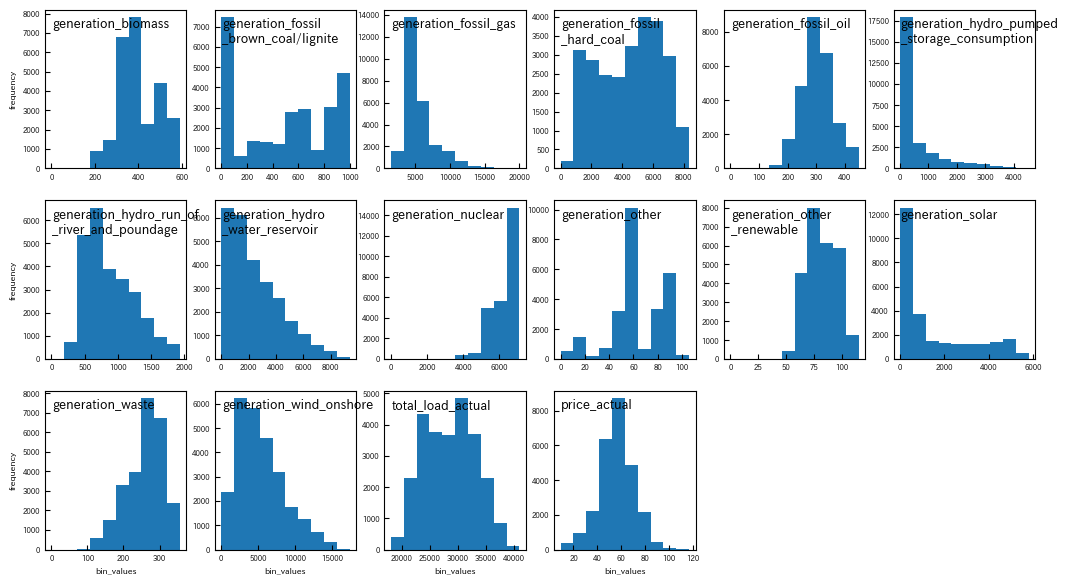

In [ ]:
y_col = "price_actual"
exclude_col = "time"
rename_dict = {
    'generation_fossil_brown_coal/lignite': 'generation_fossil\n_brown_coal/lignite',
    'generation_fossil_hard_coal': 'generation_fossil\n_hard_coal',
    'generation_hydro_pumped_storage_consumption': 'generation_hydro_pumped\n_storage_consumption',
    'generation_hydro_run_of_river_and_poundage': 'generation_hydro_run_of\n_river_and_poundage',
    'generation_hydro_water_reservoir': 'generation_hydro\n_water_reservoir',
    'generation_other_renewable': 'generation_other\n_renewable'}


hist_plot(tr_df, power_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=rename_dict,
          col_n=5, x_fig=11, y_fig=2)

## スペイン5都市の数値カラム

### valencia

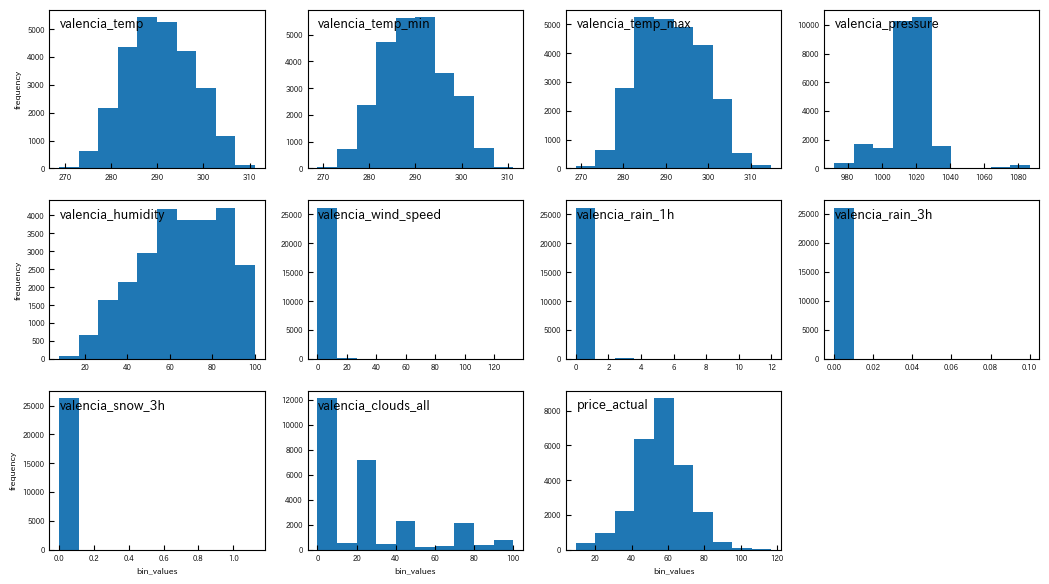

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "valencia"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
hist_plot(tr_df, barcelona_num_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=None,
          col_n=4, x_fig=11, y_fig=2)

### madrid

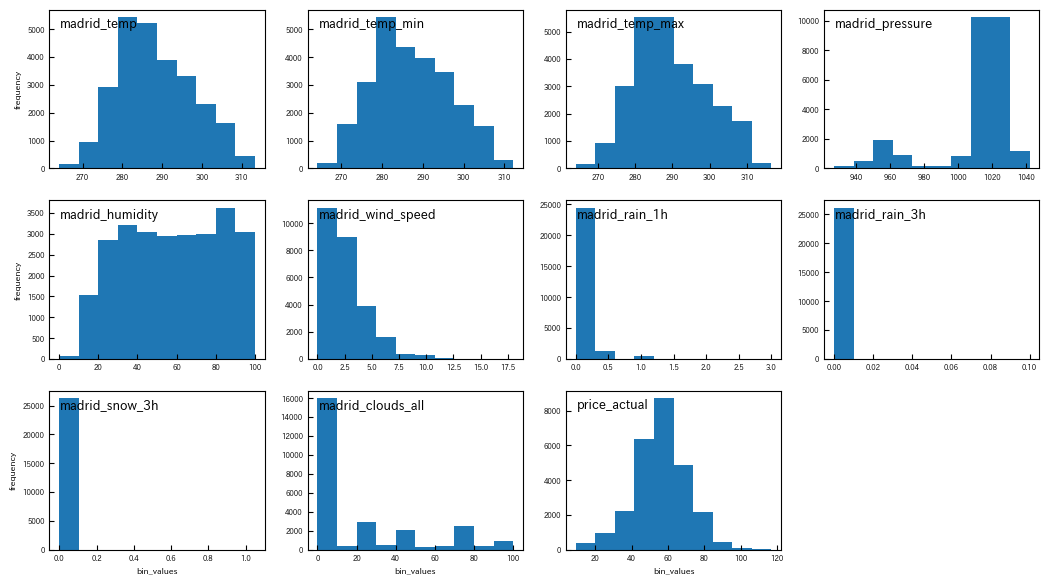

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "madrid"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
hist_plot(tr_df, barcelona_num_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=None,
          col_n=4, x_fig=11, y_fig=2)

### bilbao

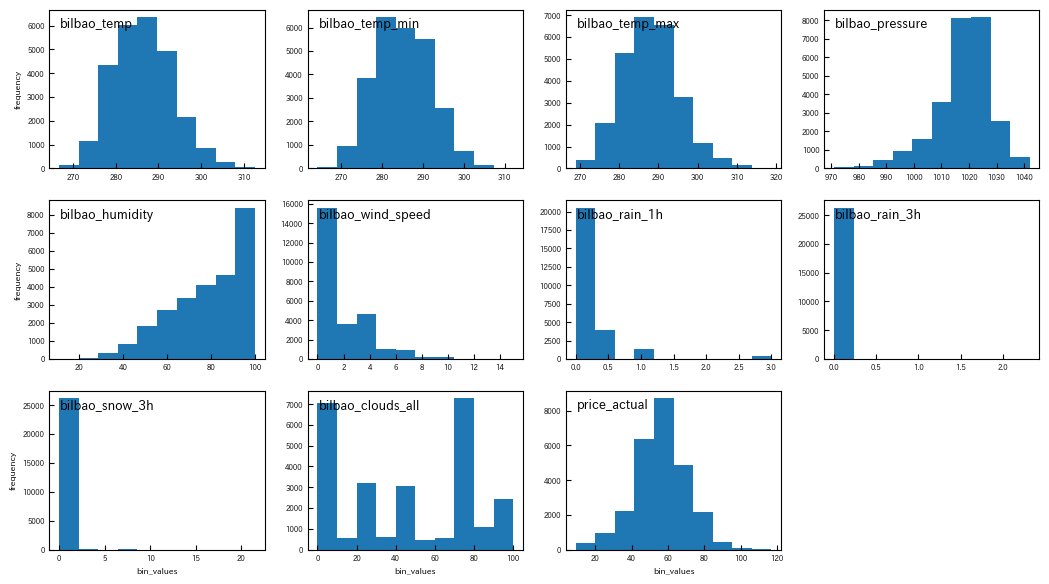

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "bilbao"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
hist_plot(tr_df, barcelona_num_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=None,
          col_n=4, x_fig=11, y_fig=2)

### barcelona

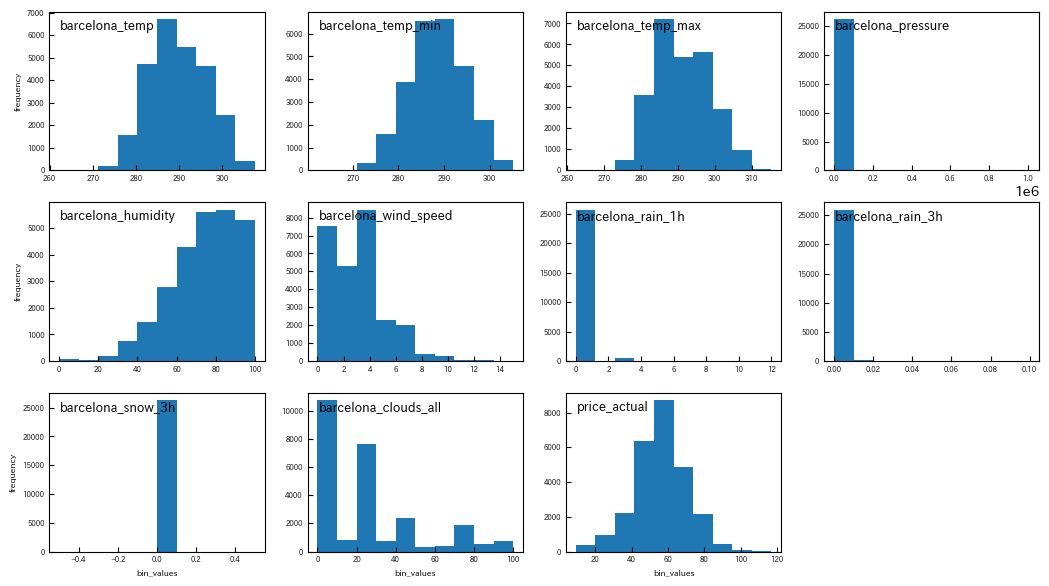

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "barcelona"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
hist_plot(tr_df, barcelona_num_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=None,
          col_n=4, x_fig=11, y_fig=2)

### seville

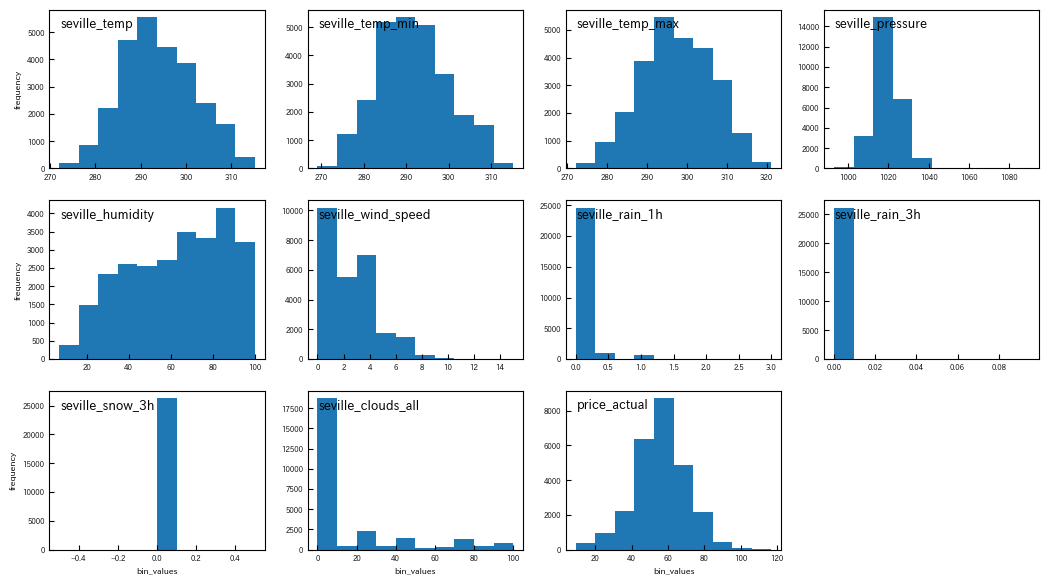

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "seville"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
hist_plot(tr_df, barcelona_num_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=None,
          col_n=4, x_fig=11, y_fig=2)

## スペイン5都市のカテゴリカラム

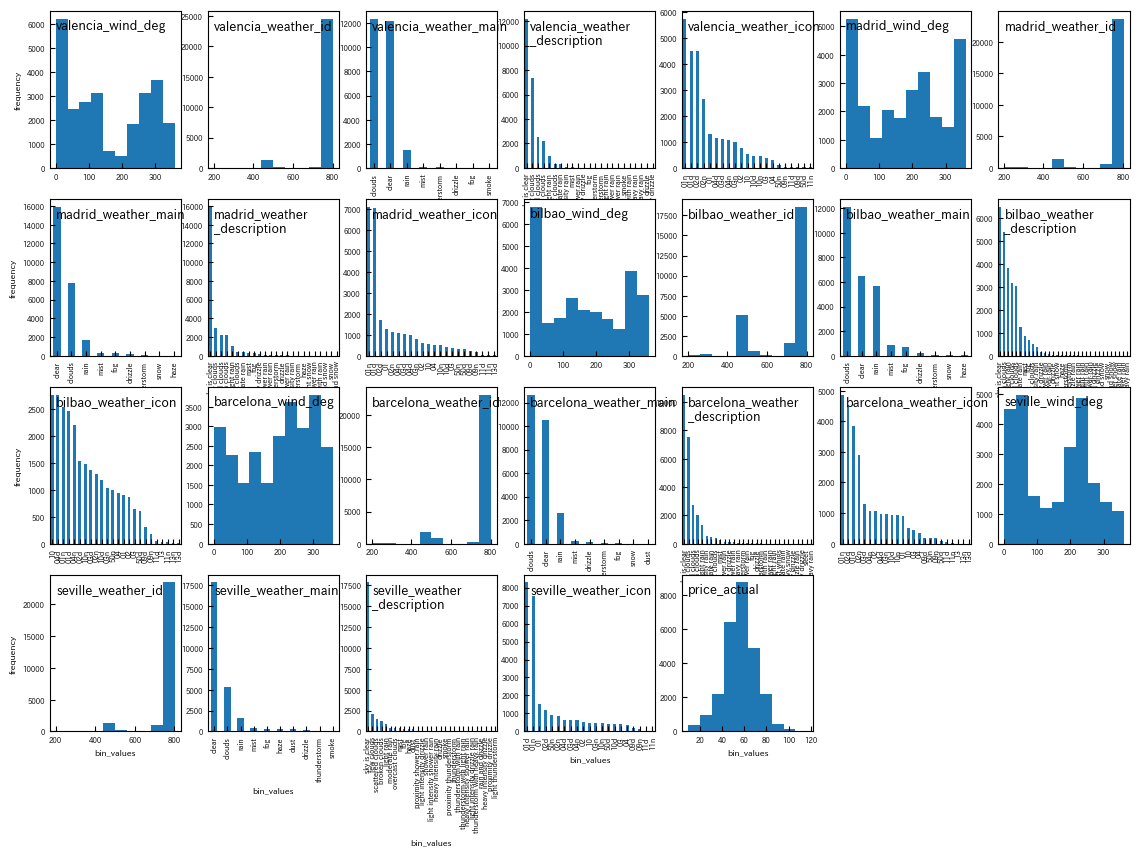

In [ ]:
y_col = "price_actual"
exclude_col = "time"
rename_dict = {
 'valencia_weather_description': 'valencia_weather\n_description',
 'madrid_weather_description': 'madrid_weather\n_description',
 'bilbao_weather_description': 'bilbao_weather\n_description',
 'barcelona_weather_description': 'barcelona_weather\n_description',
 'seville_weather_description': 'seville_weather\n_description'
}
hist_plot(tr_df, sp_cate_cols, y_col=y_col, exclude_col=exclude_col, rename_dict=rename_dict,
          col_n=7, x_fig=12, y_fig=2)

# 相関係数の分析

In [34]:
# 数値データのみに対応
def corr_heatmap(inp_df, inp_trgt_cols, y_col=None, exclude_col=None, rename_dict=None):
    df = inp_df.copy()
    trgt_cols = inp_trgt_cols.copy()
    # 相関係数の計算
    if y_col:
        trgt_cols.append(y_col)
    if exclude_col:
        if exclude_col in trgt_cols:
            trgt_cols.remove(exclude_col)
    corr = df[trgt_cols].corr()
    # renamed = [renamed_cols.get(col, col) for col in trgt_cols]
    renamed_cols = trgt_cols.copy()
    if isinstance(rename_dict, dict):

        for i, col in enumerate(renamed_cols):
            if col in rename_dict.keys():
                col = rename_dict[col]
            renamed_cols[i] = col

    corr = df[trgt_cols].corr()
    corr.columns = renamed_cols
    corr.index = renamed_cols
    # ヒートマップの描画
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr,
        annot=True,           # 数値を表示
        fmt=".2f",            # 小数2桁
        cmap="coolwarm",      # カラーマップ
        square=True,          # 正方形セル
        linewidths=0.5,       # セルの境界線
        cbar_kws={"shrink": 0.8},  # カラーバーのサイズ調整
        annot_kws={"fontsize": 7}  # 数値の文字サイズ
    )
    plt.xticks(rotation=45, fontsize=6, weight='bold')
    plt.yticks(rotation=0, fontsize=6, weight='bold')
    plt.title("Correlation Heatmap", fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()
    return corr


## 発電実績値

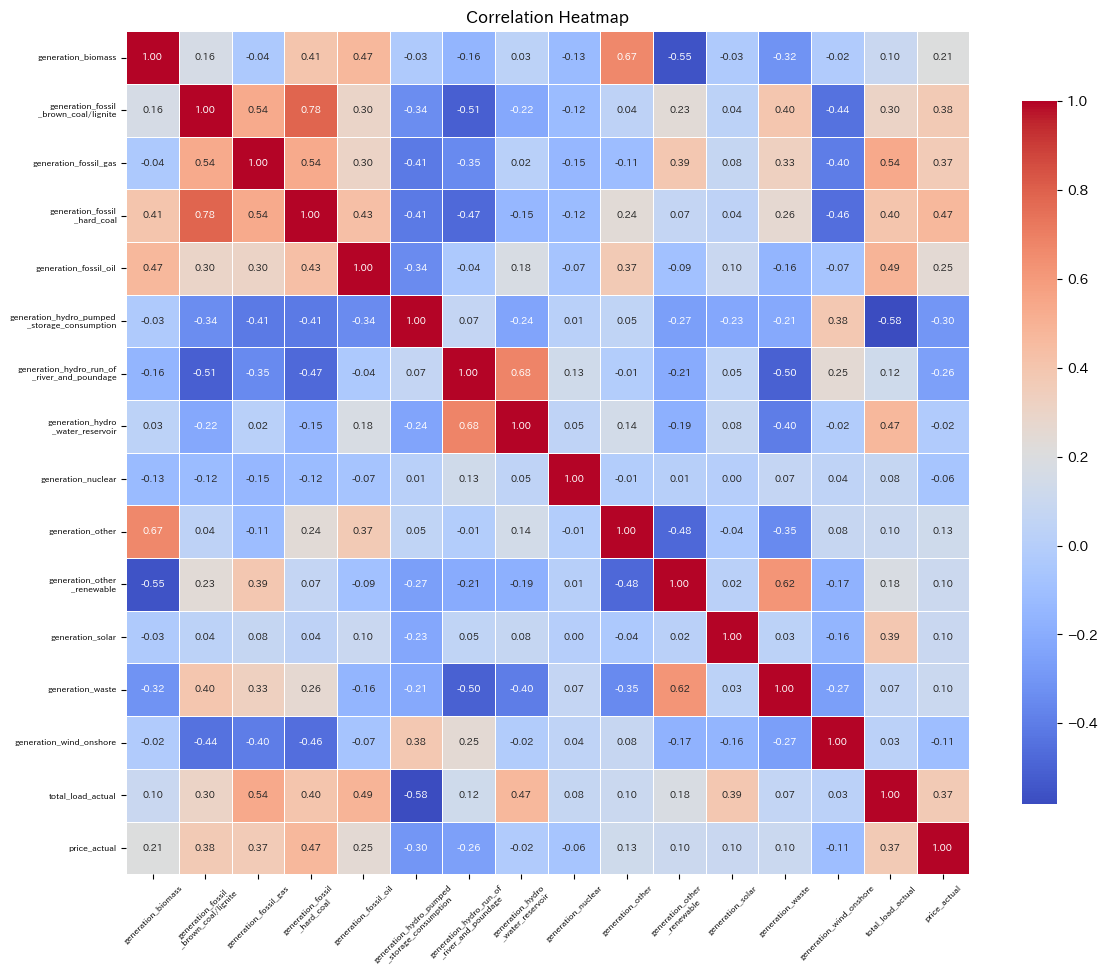

In [ ]:
rename_dict = {
    'generation_fossil_brown_coal/lignite': 'generation_fossil\n_brown_coal/lignite',
    'generation_fossil_hard_coal': 'generation_fossil\n_hard_coal',
    'generation_hydro_pumped_storage_consumption': 'generation_hydro_pumped\n_storage_consumption',
    'generation_hydro_run_of_river_and_poundage': 'generation_hydro_run_of\n_river_and_poundage',
    'generation_hydro_water_reservoir': 'generation_hydro\n_water_reservoir',
    'generation_other_renewable': 'generation_other\n_renewable'}


corr = corr_heatmap(tr_df, sp_num_cols, y_col="price_actual", exclude_col="time", rename_dict=rename_dict)

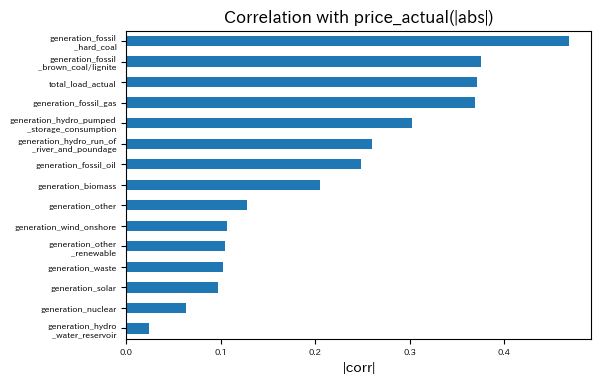

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

## スペイン5都市の数値カラム

### valencia

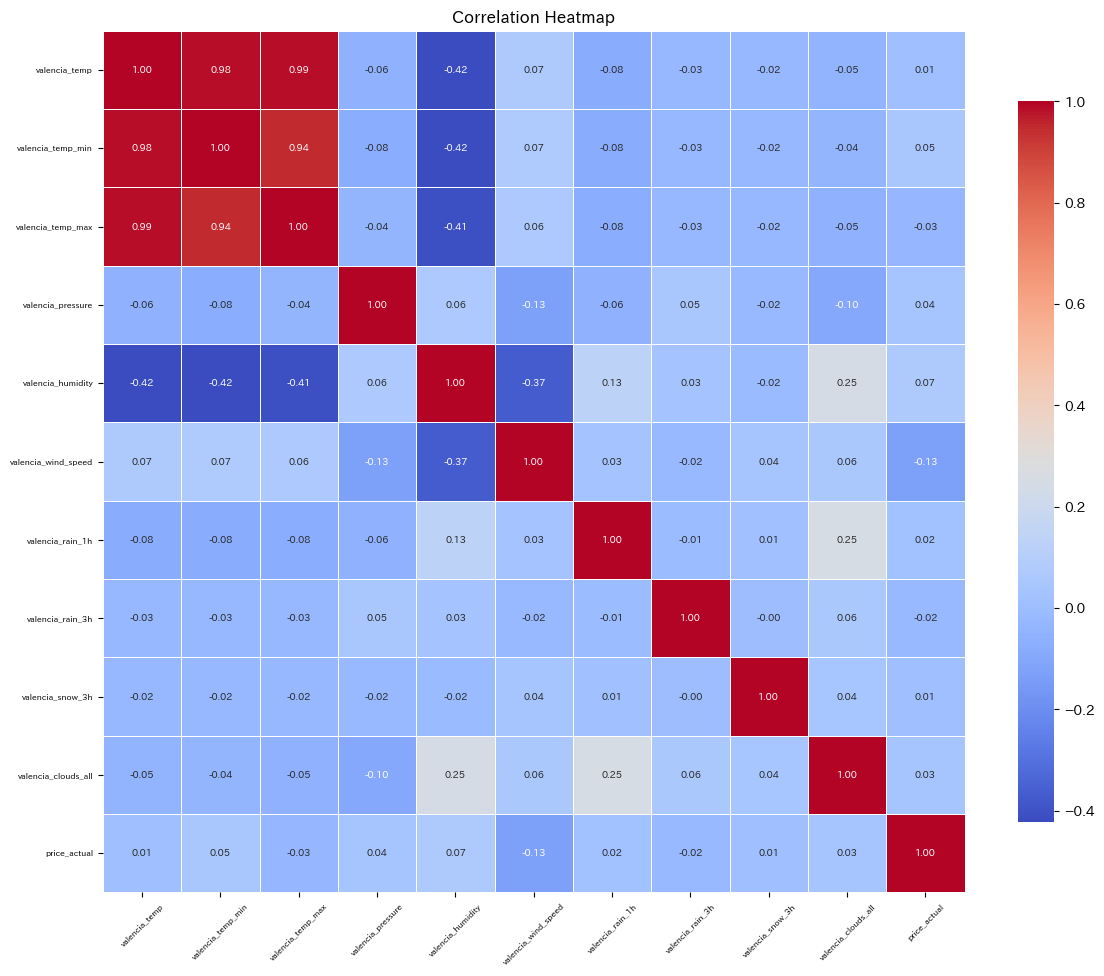

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "valencia"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
corr = corr_heatmap(tr_df, barcelona_num_cols, y_col="price_actual", exclude_col="time", rename_dict=None)

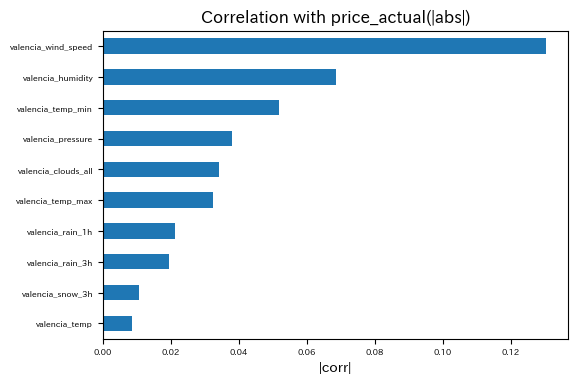

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

### madrid

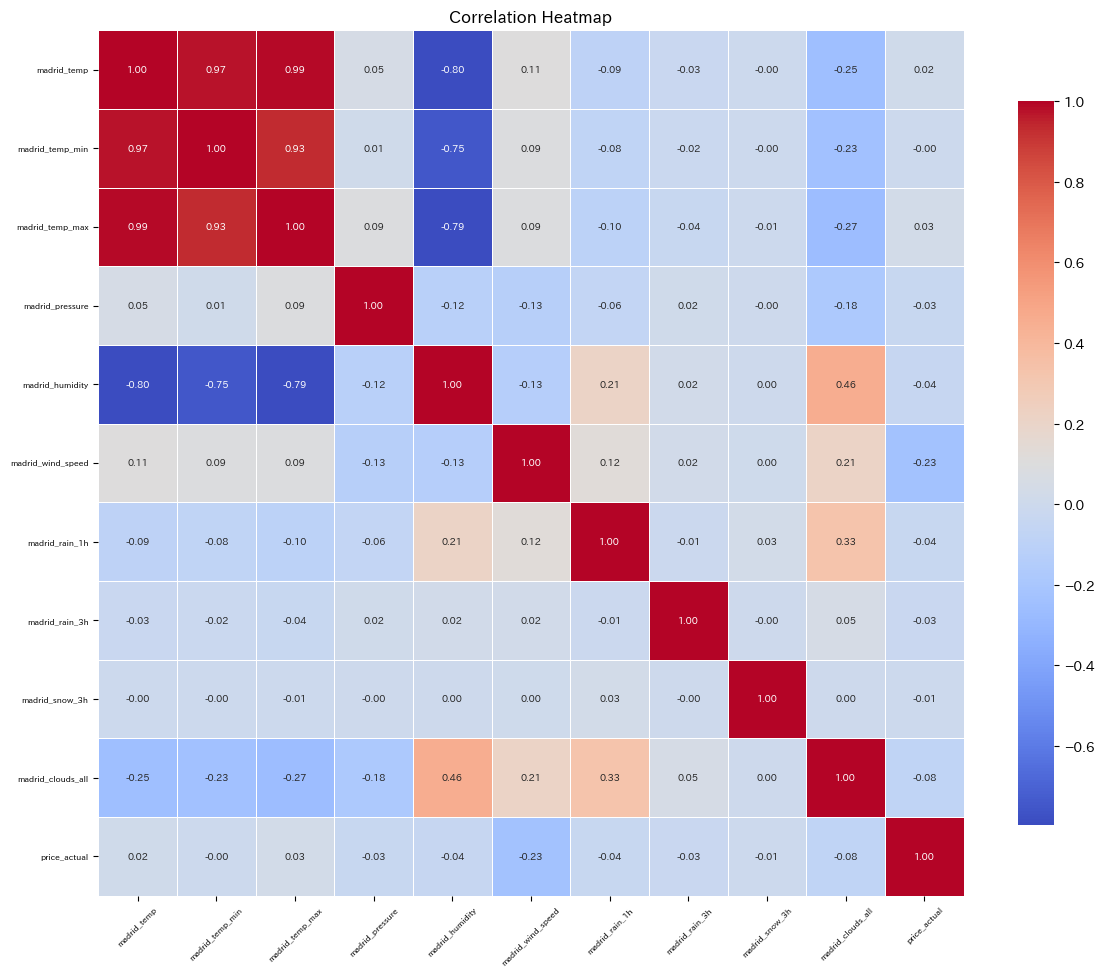

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "madrid"
madrid_num_cols = [x for x in sp_num_cols if region in x]
corr = corr_heatmap(tr_df, madrid_num_cols, y_col="price_actual", exclude_col="time", rename_dict=None)

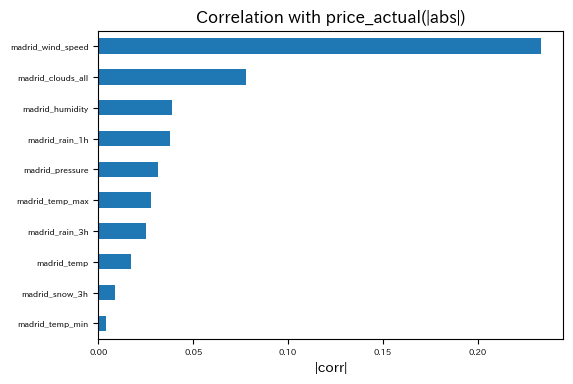

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

### bilbao

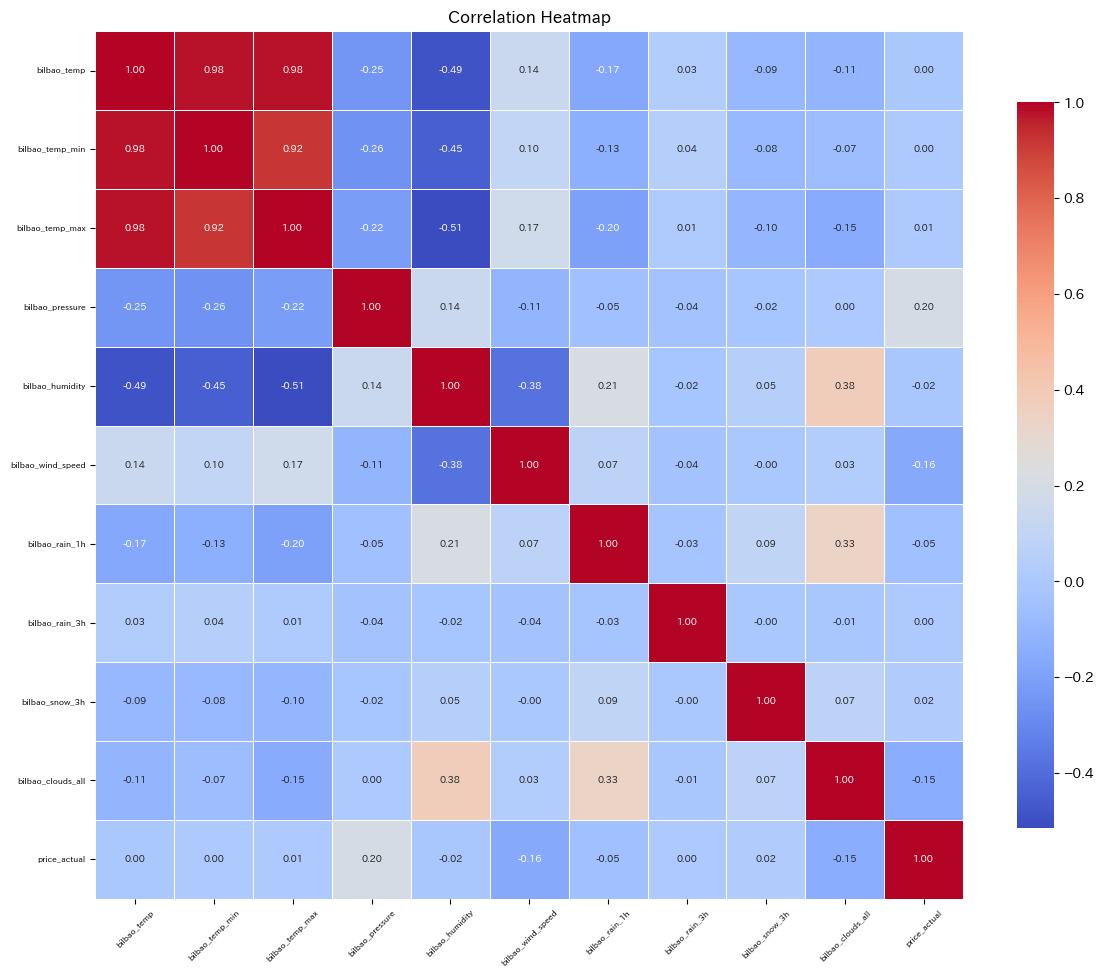

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "bilbao"
bilbao_num_cols = [x for x in sp_num_cols if region in x]
corr = corr_heatmap(tr_df, bilbao_num_cols, y_col="price_actual", exclude_col="time", rename_dict=None)

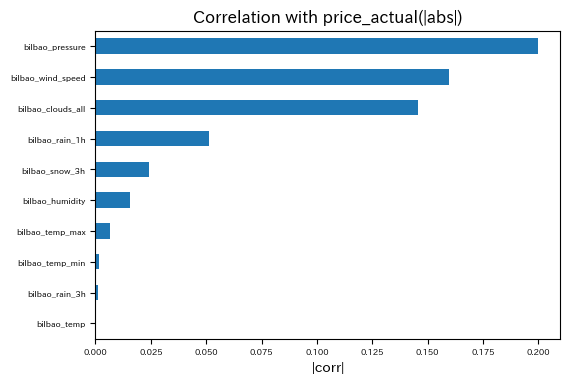

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

### barcelona

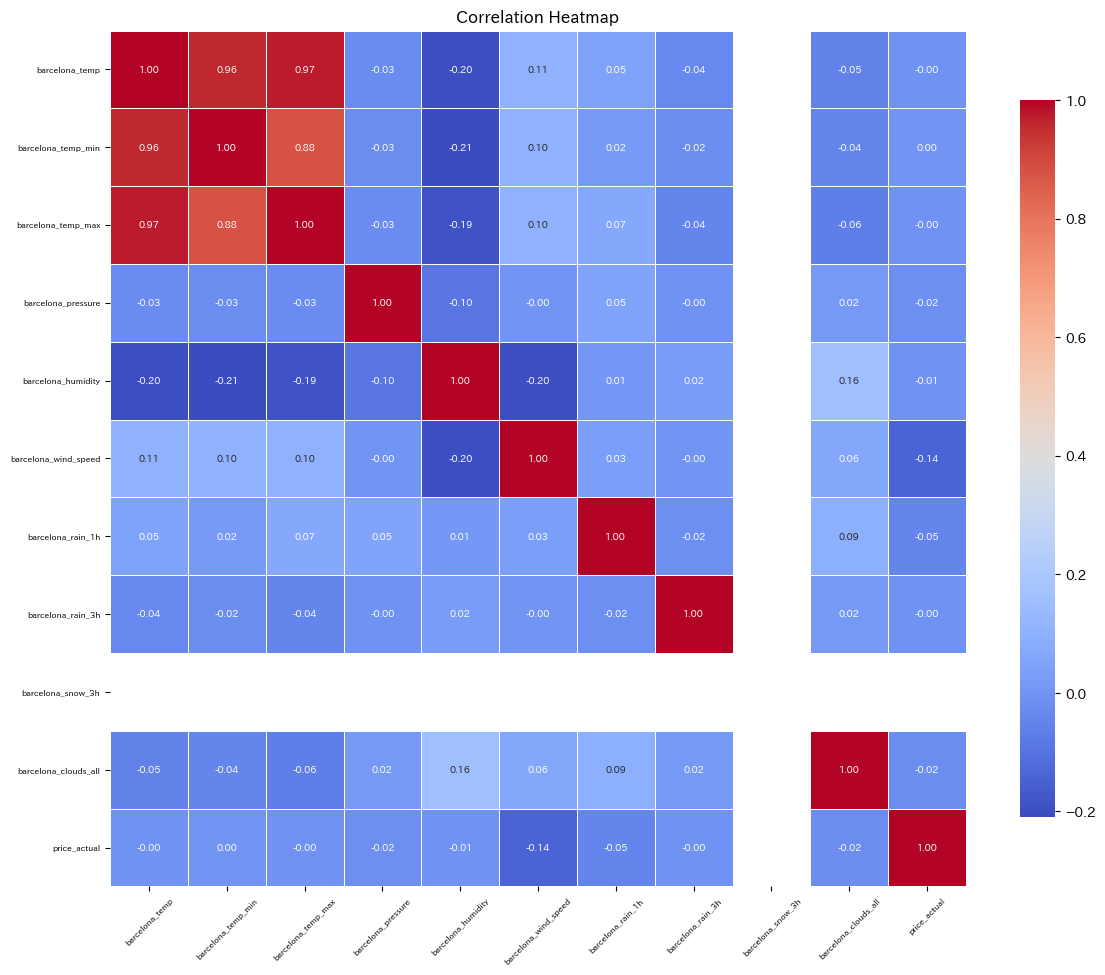

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "barcelona"
barcelona_num_cols = [x for x in sp_num_cols if region in x]
corr = corr_heatmap(tr_df, barcelona_num_cols, y_col="price_actual", exclude_col="time", rename_dict=None)

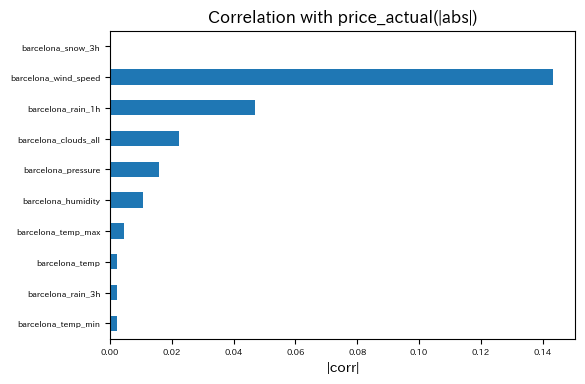

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

### seville

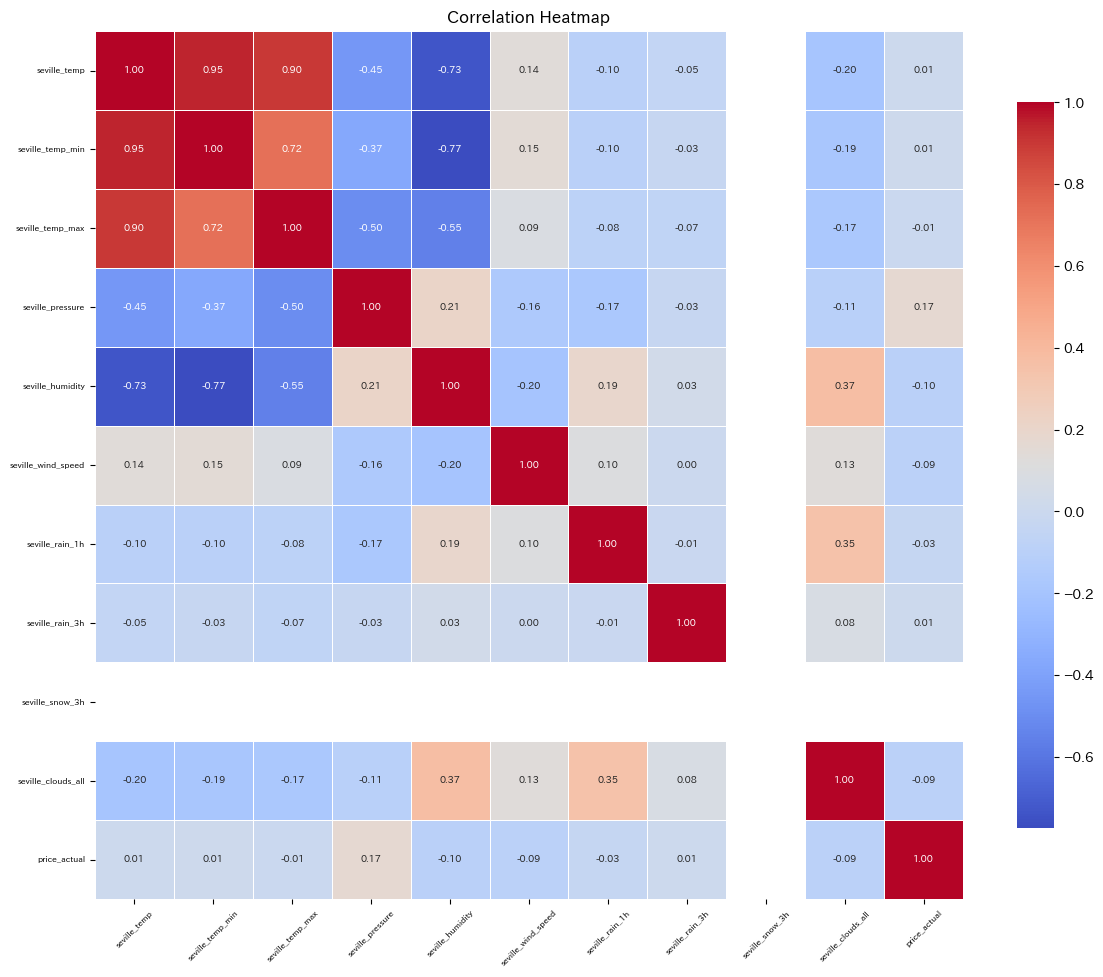

In [ ]:
y_col = "price_actual"
exclude_col = "time"
region = "seville"
seville_num_cols = [x for x in sp_num_cols if region in x]
corr = corr_heatmap(tr_df, seville_num_cols, y_col="price_actual", exclude_col="time", rename_dict=None)

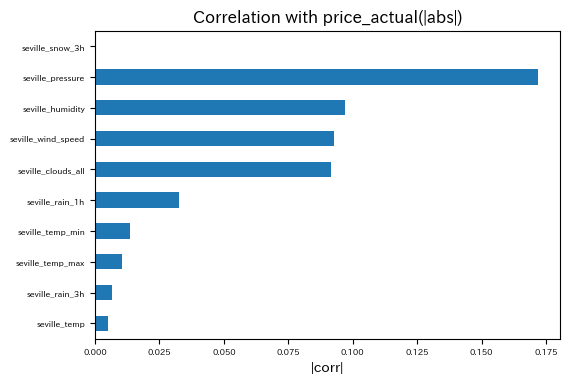

In [ ]:
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("Correlation with price_actual(|abs|)")
plt.xticks(rotation=0, ha='center', fontsize=6, fontweight='bold')  # X軸ラベルを小さく
plt.yticks(rotation=0, fontsize=6, fontweight='bold')
plt.xlabel("|corr|")
plt.show()

# 散布図の分析

In [ ]:
def plot_scatter(inp_df, trgt_cols, y_col, exclude_col=None, rename_dict=None):
    df = inp_df.copy()
    n = len(trgt_cols)
    col_n = 5
    row_n = math.ceil(n / col_n)

    # サブプロット作成
    fig, axes = plt.subplots(row_n, col_n, figsize=(12, row_n * 2), sharex=False)
    axes = axes.flatten()

    # 図と図の間の余白を調整
    plt.subplots_adjust(
        left=0.05, right=0.95, top=0.95, bottom=0.05,
        wspace=0.2, hspace=0.2
    )

    for i, (ax, col) in enumerate(zip(axes, trgt_cols)):
        # タイトル整形（長い列は改行）
        label = col
        if isinstance(rename_dict, dict):
            if col in rename_dict.keys():
                label = rename_dict[col]



        # 散布図描画
        ax.scatter(df[col], df[y_col], s=1, alpha=0.5)
        sns.regplot(x=df[col], y=df[y_col], scatter=False, color="red", ax=ax)

        # タイトルを図内に表示
        ax.text(0.05, 0.95, label, fontsize=7, va='top', ha='left', transform=ax.transAxes)

        # y軸（左端列のみ）
        if i % col_n == 0:
            ax.set_ylabel("value", fontsize=6, fontweight='bold')
            ax.tick_params(axis='y', direction='in', labelsize=5)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', left=False, right=False, labelleft=False)

        # x軸（最下段のみ）
        if i // col_n == row_n - 1:
            ax.set_xlabel(f"{col}", fontsize=6, fontweight='bold')
            ax.tick_params(axis='x', direction='in', labelsize=5, rotation=45)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)

    # 使わなかったサブプロットを非表示
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.show()

## 発電実績値

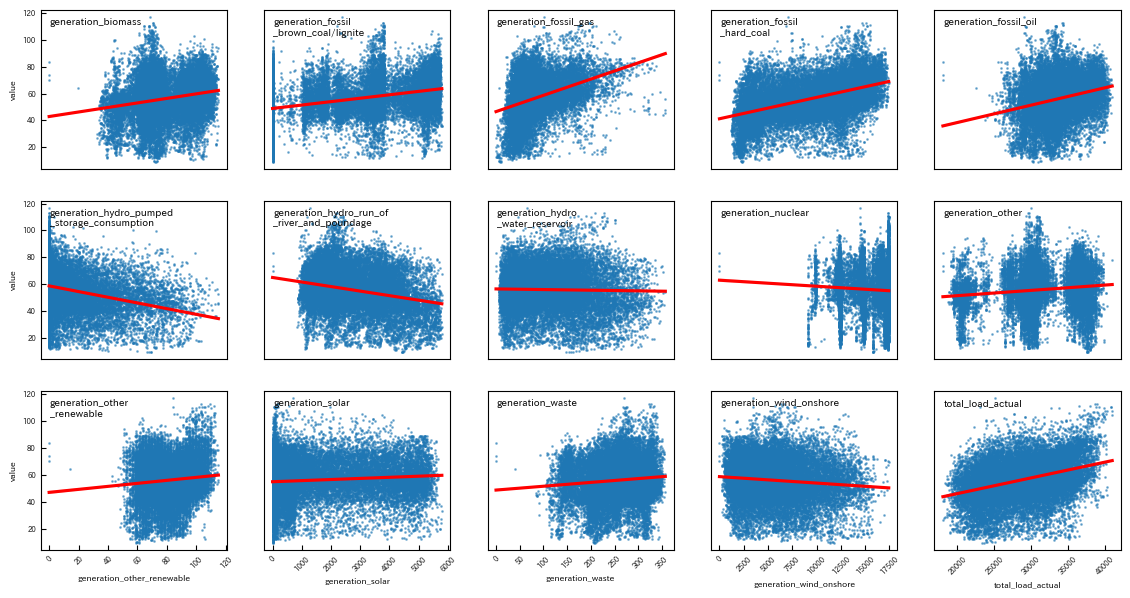

In [ ]:
plot_scatter(tr_df, power_cols, "price_actual", exclude_col="time", rename_dict=rename_dict)

## スペイン5都市の数値カラム

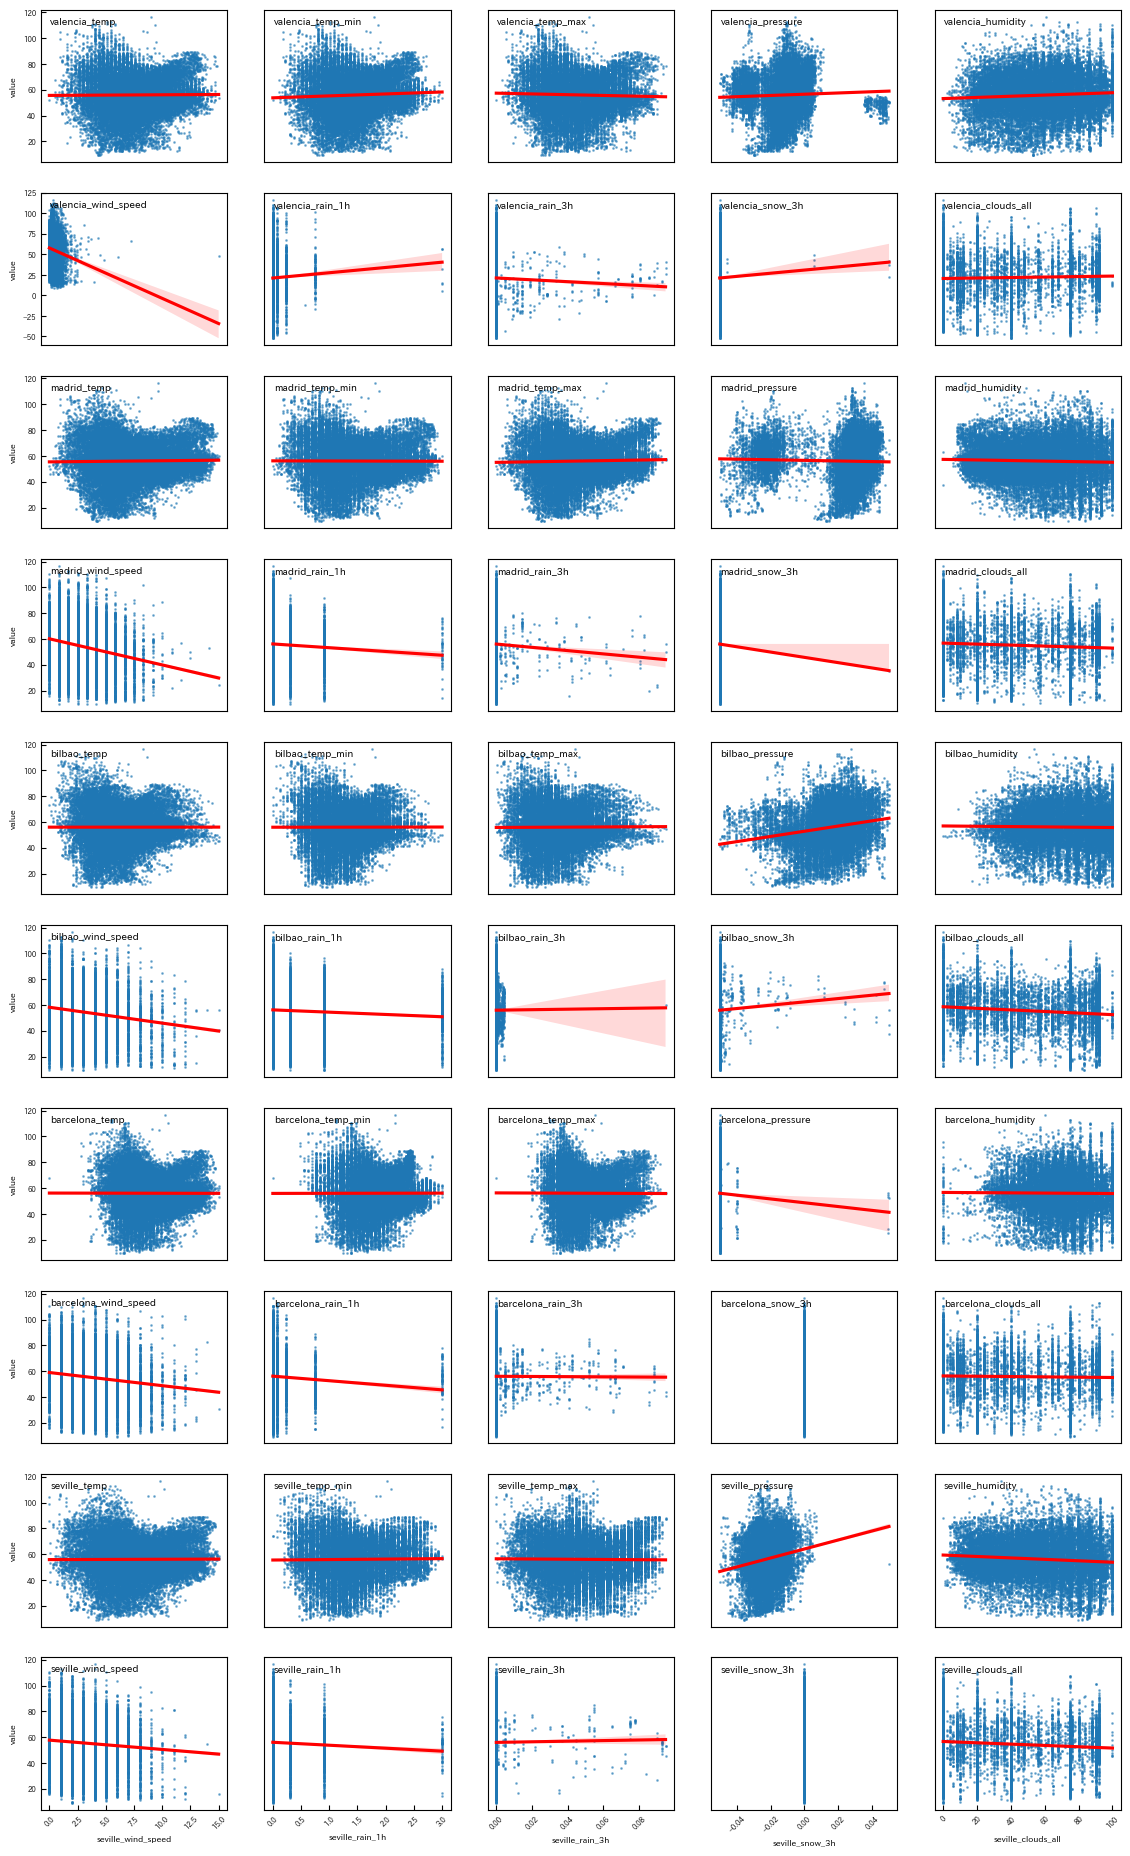

In [ ]:
plot_scatter(tr_df, sp_num_cols, "price_actual", exclude_col="time")

# ヒストグラムと割合

generation_biomass
generation_fossil_brown_coal/lignite
generation_fossil_gas
generation_fossil_hard_coal
generation_fossil_oil
generation_hydro_pumped_storage_consumption
generation_hydro_run_of_river_and_poundage
generation_hydro_water_reservoir
generation_nuclear
generation_other
generation_other_renewable
generation_solar
generation_waste
generation_wind_onshore
total_load_actual


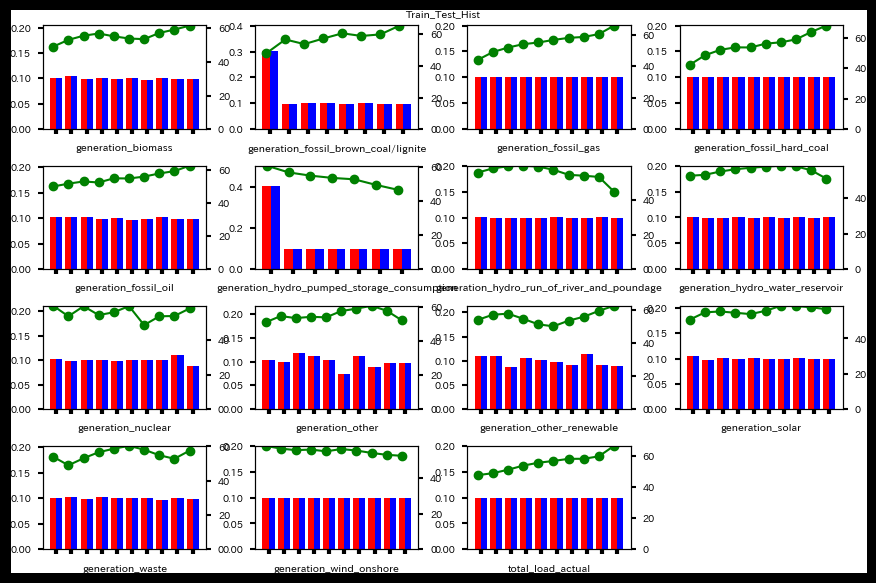

In [ ]:
trgt_y = 'price_actual'
trgt_cols = ["generation_biomass",
"generation_fossil_brown_coal/lignite",
"generation_fossil_gas",
"generation_fossil_hard_coal",
"generation_fossil_oil",
"generation_hydro_pumped_storage_consumption",
"generation_hydro_run_of_river_and_poundage",
"generation_hydro_water_reservoir",
"generation_nuclear",
"generation_other",
"generation_other_renewable",
"generation_solar",
"generation_waste",
"generation_wind_onshore",
"total_load_actual"]
tmp_tr, tmp_test, bin_values = cnvrt_hist(tr_df=tr_df, test_df=test_df,
                                          trgt_y=trgt_y, trgt_cols=trgt_cols,
                                          row_num=5, col_num=4, id_col="time", bins=10, return_df=True)

# feats engineering

## カラムの除去

In [10]:
# いらないカラムを消す
cate_cols = [
             "valencia_snow_3h",
             "valencia_weather_id",
             "valencia_weather_main",
             "valencia_weather_icon",
             "madrid_snow_3h",
             "madrid_weather_id",
             "madrid_weather_main",
             "madrid_weather_icon",
             "bilbao_snow_3h",
             "bilbao_weather_id",
             "bilbao_weather_main",
             "bilbao_weather_icon",
             "barcelona_snow_3h",
             "barcelona_weather_id",
             "barcelona_weather_main",
             "barcelona_weather_icon",
             "seville_snow_3h",
             "seville_weather_id",
             "seville_weather_main",
             "seville_weather_icon"]

_tr_df_1 = row_tr_df.copy().drop(cate_cols, axis=1)
_test_df_1 = row_test_df.copy().drop(cate_cols, axis=1)
tr_df = _tr_df_1.copy()
test_df = _test_df_1.copy()

## convrt_date

In [11]:
def convrt_date(inp_df, col = "time"):
    df = inp_df.copy()
    df["id"] = df["time"]
    df[col] = pd.to_datetime(df[col], utc=True)
    tmp_df = pd.DataFrame({
            "year": df[col].dt.year,
            "month": df[col].dt.month,
            "day": df[col].dt.day,
            "hour": df[col].dt.hour
        })
    tmp_cols = ["year", "month", "day", "hour"]
    df[tmp_cols] = tmp_df[tmp_cols]
    df = df.sort_values(["year", "month", "day", "hour"])
    tmp_cols = ["year", "month", "day", "hour"]
    df[tmp_cols] = tmp_df[tmp_cols].astype("str")
    df.drop(["hour"], axis=1, inplace=True)

    return df

_tr_df_2 = convrt_date(_tr_df_1)
_test_df_2 = convrt_date(_test_df_1)

tr_df = _tr_df_2.copy()
test_df = _test_df_2.copy()

## cnvrt_sincos()

In [12]:
def cnvrt_sincos(inp_df):
    df = inp_df.copy()
    tmp_df = df['time'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * tmp_df/12)
    df['month_cos'] = np.cos(2 * np.pi * tmp_df/12)

    tmp_df = df['time'].dt.weekday
    df['weekday_sin'] = np.sin(2 * np.pi * tmp_df/7)
    df['weekday_cos'] = np.cos(2 * np.pi * tmp_df/7)

    tmp_df = df['time'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * tmp_df / 365)
    df['day_cos'] = np.cos(2 * np.pi * tmp_df / 365)

    tmp_df = df['time'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * tmp_df/24)
    df['hour_cos'] = np.cos(2 * np.pi * tmp_df/24)

    df.drop(["time"], axis=1, inplace=True)

    return df

_tr_df_3 = cnvrt_sincos(_tr_df_2)
_test_df_3 = cnvrt_sincos(_test_df_2)

## cnvrt_energy_ratio()

In [13]:
import re

# 抽出したいキーワード（正しいスペルに修正）
p = r"biomass|fossil_brown_coal/lignite|fossil_gas|fossil_hard_coal|\
fossil_oil|hydro_pumped_storage_consumption|hydro_run_of_river_and_poundage|\
hydro_water_reservoir|nuclear|other|other_renewable|solar|waste|\
wind_onshore"

# 正規表現コンパイル
pattern = re.compile(p)

# パターンにマッチする列を抽出
cols = [col for col in row_tr_df.columns if pattern.search(col)]

def cnvrt_energy_ratio(inp_df, cols):
    df = inp_df.copy()
    for col in cols:
        df[f"{col}_ratio"] = df[f"{col}"] / df["total_load_actual"]
        df[f"{col}_ratio"] = df[f"{col}_ratio"].ffill()
    return df

_tr_df_4 = cnvrt_energy_ratio(_tr_df_3, cols)
_test_df_4 = cnvrt_energy_ratio(_test_df_3, cols)

tr_df = _tr_df_4.copy()
test_df = _test_df_4.copy()

In [14]:
trgt_cols = list(tr_df.select_dtypes(include='float64').columns)
_trgt_cols = list(tr_df.select_dtypes(include='int64').columns)
trgt_cols = trgt_cols + _trgt_cols
trgt_cols.remove("price_actual")

## gene_agg()

In [15]:
def gene_agg(inp_df, grp_cols, trgt_cols, agg_funcs):
    """
    集約特徴量を作成（グループキーがあってもなくても対応）

    Parameters:
    - df: pd.DataFrame
    - grp_cols: str or list of str or None
        None の場合は全体で集約
    - trgt_cols: list of str
        集約対象カラム
    - agg_funcs: list of str
        使いたい集約関数（例：["mean", "std", "min", "max"]）

    Returns:
    - pd.DataFrame: 元データに集約特徴量を結合したもの
    """
    df = inp_df.copy()

    # grp_colsの処理
    if grp_cols is None:
        # 全体集約（各行に同じ値を付加）
        for col in trgt_cols:
            for func in agg_funcs:
                agg_val = getattr(df[col], func)()
                new_col = f'{col}_{func}'
                df[new_col] = agg_val
        return df

    if isinstance(grp_cols, str):
        grp_cols = [grp_cols]

    group_name = "_".join(grp_cols)

    # グループ単位で集約
    grouped = df.groupby(grp_cols)[trgt_cols].agg(agg_funcs)
    grouped.columns = [
        f'{group_name}_{col}_{func}' for col, func in grouped.columns
    ]
    grouped = grouped.reset_index()
    # 元データにマージ（集約特徴量を行単位に展開）
    df = df.merge(grouped, on=grp_cols, how='left')
    return df

In [16]:
grp_cols = ["year", "month"]
_tr_df_5 = gene_agg(_tr_df_4, grp_cols, trgt_cols, ["mean"])
_test_df_5 = gene_agg(_test_df_4, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_5.copy()
test_df = _test_df_5.copy()

In [17]:
_trgt_cols = trgt_cols.copy()
grp_cols = ["year", "month", "valencia_weather_description"]
trgt_cols = [col for col in _trgt_cols if "valencia" in col]
_tr_df_6 = gene_agg(_tr_df_5, grp_cols, trgt_cols, ["mean"])
_test_df_6 = gene_agg(_test_df_5, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_6.copy()
test_df = _test_df_6.copy()

In [18]:
grp_cols = ["year", "month", "madrid_weather_description"]
trgt_cols = [col for col in _trgt_cols if "madrid" in col]
_tr_df_7 = gene_agg(_tr_df_6, grp_cols, trgt_cols, ["mean"])
_test_df_7 = gene_agg(_test_df_6, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_7.copy()
test_df = _test_df_7.copy()

In [19]:
grp_cols = ["year", "month", "bilbao_weather_description"]
trgt_cols = [col for col in _trgt_cols if "bilbao" in col]
_tr_df_8 = gene_agg(_tr_df_7, grp_cols, trgt_cols, ["mean"])
_test_df_8 = gene_agg(_test_df_7, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_8.copy()
test_df = _test_df_8.copy()

In [20]:
grp_cols = ["year", "month", "barcelona_weather_description"]
trgt_cols = [col for col in _trgt_cols if "barcelona" in col]
_tr_df_9 = gene_agg(_tr_df_8, grp_cols, trgt_cols, ["mean"])
_test_df_9 = gene_agg(_test_df_8, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_9.copy()
test_df = _test_df_9.copy()

In [21]:
grp_cols = ["year", "month", "seville_weather_description"]
trgt_cols = [col for col in _trgt_cols if "seville" in col]
_tr_df_10 = gene_agg(_tr_df_9, grp_cols, trgt_cols, ["mean"])
_test_df_10 = gene_agg(_test_df_9, grp_cols, trgt_cols, ["mean"])
tr_df = _tr_df_10.copy()
test_df = _test_df_10.copy()

## gene_lag()

In [ ]:
# import pandas as pd

# def gene_lag(df, grp_cols, trgt_cols, lags):
#     df = df.copy()

#     # grp_colsの準備
#     if grp_cols is None:
#         grp_cols = None
#     elif isinstance(grp_cols, str):
#         grp_cols = [grp_cols]

#     for col in trgt_cols:
#         for lag in lags:
#             if grp_cols is None:
#                 # グループなし → シンプルなカラム名
#                 lag_col = f'{col}_lag{lag}'
#                 df[lag_col] = df[col].shift(lag)
#             else:
#                 # グループあり → グループキー含むカラム名
#                 group_name = "_".join(grp_cols)
#                 lag_col = f'{group_name}_{col}_lag{lag}'
#                 df[lag_col] = df.groupby(grp_cols)[col].shift(lag)

#             # 欠損補完
#             if pd.api.types.is_numeric_dtype(df[lag_col]):
#                 df[lag_col] = df[lag_col].fillna(df[lag_col].mean())
#             else:
#                 mode_val = df[lag_col].mode()
#                 df[lag_col] = df[lag_col].fillna(mode_val[0])

#     return df


# # grp_cols = ["year", "month"]
# grp_cols = []

# # 例：city単位で1日と2日ラグを生成
# tr_df = gene_lag(_tr_df_9, grp_cols, _trgt_cols, lags=[24, ])
# test_df = gene_lag(_test_df_9, grp_cols, _trgt_cols, lags=[1, 2])

In [ ]:
# tr_df, test_df = trgt_encd(tr_df, test_df, "seville_weather_description", "price_actual")

## gene_city_clusters()

In [22]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def gene_city_clusters(inp_df, cities, trgt_cols = [], n_pca=5, n_clusters=5):
    """
    指定ラベルでグルーピングしてPCA → KMeansクラスタリングを行い、クラスタIDを特徴量として追加

    Parameters:
        df: pandas.DataFrame
        cities: list of str - 都市名のリスト (例: ["valencia", "madrid", ...])
        n_pca: int - PCAで次元圧縮する次元数
        n_clusters: int - クラスタ数

    Returns:
        df: クラスタID付きのDataFrame
    """
    df = inp_df.copy()
    for city in cities:
        # 都市ごとの都市に関わるカラムを抽出
        if trgt_cols:
            cols = [col for col in trgt_cols if city in col and not df[col].dtype == "object"]
        else:
            cols = [col for col in df.columns if city in col and not df[col].dtype == "object"]

        # 欠損がある場合の処理（PCAやKMeansはNaN不可）
        # city_data = df[cols].fillna(df[cols].mean())
        city_data = df[cols].fillna("ffill", axis=0)

        # 標準化
        scaler = StandardScaler()
        city_data = scaler.fit_transform(city_data)

        # PCA
        pca = PCA(n_components=n_pca, random_state=0)
        pca_features = pca.fit_transform(city_data)

        # クラスタリング
        kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(pca_features)

        # 新しい特徴量としてクラスタIDを追加
        df[f"{city}_cluster"] = cluster_labels.astype("str")

    return df


In [23]:
cities = ["valencia", "madrid",
          "bilbao", "barcelona",
          "seville"]

_tr_df_11 = gene_city_clusters(_tr_df_10, cities)
_test_df_11 = gene_city_clusters(_test_df_10, cities)

In [25]:
cate_col_lst = list(_tr_df_11.select_dtypes(include='object').columns)
cate_col_lst = [x for x in cate_col_lst if x not in ["year", "month", "day", "id"]]
cate_col_lst

['valencia_weather_description',
 'madrid_weather_description',
 'bilbao_weather_description',
 'barcelona_weather_description',
 'seville_weather_description',
 'valencia_cluster',
 'madrid_cluster',
 'bilbao_cluster',
 'barcelona_cluster',
 'seville_cluster']

## trgt_encd()

In [24]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit

import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

def trgt_encd(inp_tr, inp_test, grpby_col_lst, cate_col_lst, y_col, n_split=5, max_train_size=8760, gap=168):
    tr_df = inp_tr.copy()
    test_df = inp_test.copy()
    _grpby_col = grpby_col_lst.copy()
    for cate_col in cate_col_lst:
        grpby_col = _grpby_col.copy()
        grpby_col.append(cate_col)
        col_name = "_".join(grpby_col)
        te_col_name = f'{col_name}_te'
        tr_df[te_col_name] = np.nan
        means_stds = tr_df.groupby(grpby_col)[y_col].agg(["mean", "std"]).reset_index()
        # means_stds["std"] = means_stds["std"].fillna(means_stds["std"].mean())
        # means_stds["mean_new"] = np.random.normal(loc=means_stds["mean"], scale=means_stds["std"])

        # print(means_stds)
        # import pdb; pdb.set_trace()
        means_stds.rename(columns={"mean": te_col_name}, inplace=True)
        tmp_cols = grpby_col + [te_col_name]

        # import pdb; pdb.set_trace()
        tr_df[te_col_name] = pd.merge(tr_df[grpby_col], means_stds[tmp_cols], on=grpby_col, how='left')[te_col_name].values
        mean = tr_df[te_col_name].mean()
        std = tr_df[te_col_name].std()
        test_df[te_col_name] = np.random.normal(loc=mean, scale=std, size=len(test_df))

    return tr_df, test_df


        # tscv = TimeSeriesSplit(n_splits=n_split, max_train_size=max_train_size, gap=gap)

        # for tr_idx, val_idx in tscv.split(tr_df):
        #     trn_fold = tr_df.iloc[tr_idx]
        #     val_fold = tr_df.iloc[val_idx]
        #     means = trn_fold.groupby(grpby_col)[y_col].mean().reset_index()
        #     means.rename(columns={y_col: te_col_name}, inplace=True)
        #     means_val = means[f"{te_col_name}"].mean()
        #     tr_df.loc[val_idx, te_col_name] = means_val
            # tr_df.loc[val_idx, te_col_name] = pd.merge(
            #     val_fold[grpby_col], means, on=grpby_col, how='left')[te_col_name].values
            # print(means_val)
            # print(tr_df.loc[val_idx, te_col_name])
            # import pdb; pdb.set_trace()

            # tr_df.loc[val_idx, te_col_name] = pd.merge(
            #     val_fold[grpby_col], means, on=grpby_col, how='left')[te_col_name].values

            # tr_df.loc[val_idx, te_col_name] = pd.merge(
            #     val_fold[grpby_col], means, on=grpby_col, how='left')[te_col_name].values

            # tmp = val_fold[grpby_col][:5]

            # tmp_2 = means
            # tmp = pd.merge(val_fold[grpby_col], means, on=grpby_col, how='left')
            # tmp_2 = pd.merge(val_fold[grpby_col], means, on=grpby_col, how='left')[te_col_name].values

            # print(tmp)
            # print("-----------")
            # print(tmp_2)
            # import pdb; pdb.set_trace()

        # overall_means = tr_df.groupby(grpby_col)[y_col].mean().reset_index()
        # overall_means.rename(columns={y_col: te_col_name}, inplace=True)

        # test_df[te_col_name] = pd.merge(
        #     test_df[grpby_col], overall_means, on=grpby_col, how='left')[te_col_name].values

    return tr_df, test_df


In [26]:
# cate_cols = list(_tr_df_11.select_dtypes(include='object').columns)
y_col = "price_actual"
grpby_col_lst = ["year", "month"]
# grpby_col =
# inp_tr, inp_test, grpby_col, cate_cols, y_col, n_split=5, max_train_size=8760, gap=168
_tr_df_12, _test_df_12 = trgt_encd(_tr_df_11, _test_df_11, grpby_col_lst,  cate_col_lst, y_col)

In [77]:
tr_df = _tr_df_12.copy()
test_df = _test_df_12.copy()
# tr_df.drop(["year", "month"], axis=1, inplace=True)
# test_df.drop(["year", "month"], axis=1, inplace=True)
tr_df = tr_df.ffill(axis=0)
test_df = test_df.ffill(axis=0)

In [78]:
# tr_df = _tr_df_12.copy()
# test_df = _test_df_12.copy()

# tr_df = tr_df.ffill(axis=0)
# test_df = test_df.ffill(axis=0)

drop_cols = ["valencia_weather_description",
 "madrid_weather_description",
 "bilbao_weather_description",
 "barcelona_weather_description",
 "seville_weather_description",
 "year", "month", "day"]

tr_df.drop(drop_cols, axis=1, inplace=True)
test_df.drop(drop_cols, axis=1, inplace=True)

to_cate_cols = ["valencia_cluster",
 "madrid_cluster",
 "bilbao_cluster",
 "barcelona_cluster",
 "seville_cluster",
 "id"]
num_cols = [x for x in tr_df.columns if x not in to_cate_cols]

tr_df[to_cate_cols] = tr_df[to_cate_cols].astype("category")
test_df[to_cate_cols] = test_df[to_cate_cols].astype("category")
tr_df[num_cols] = tr_df[num_cols].astype("float64")
num_cols = [x for x in num_cols if x != "price_actual"]
test_df[num_cols] = test_df[num_cols].astype("float64")

In [79]:
drop_cols = ["valencia_cluster", "madrid_cluster", "barcelona_cluster", "seville_cluster", "bilbao_cluster"]
tr_df = tr_df.drop(drop_cols, axis=1)
test_df = test_df.drop(drop_cols, axis=1)

## 相関係数閾値以下のカラム除去

In [80]:
_tr_df = tr_df.drop("id", axis=1)
corr = _tr_df.corr()
# plt.figure(figsize=(8,6))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
# plt.title("価格と主要変数の相関")
# plt.show()
# print()
abs_corr = corr["price_actual"].drop("price_actual").abs().sort_values(ascending=True)
tmp_cols = list(abs_corr[abs_corr < 0.1].index)
abs_corr = abs_corr.drop(tmp_cols, axis=0)
# abs_corr.plot(kind="barh", figsize=(6,4))
# plt.title("価格との相関（絶対値）")
# plt.xlabel("|corr|")
# plt.show()

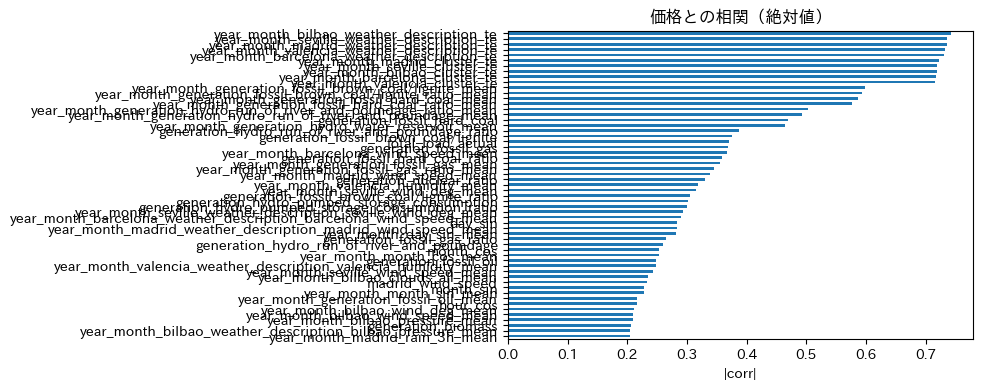

In [57]:
abs_corr.plot(kind="barh", figsize=(6,4))
plt.title("価格との相関（絶対値）")
plt.xlabel("|corr|")
plt.show()

In [81]:
tr_df = tr_df.drop(tmp_cols, axis=1)
test_df = test_df.drop(tmp_cols, axis=1)

In [84]:
tr_df

,generation_biomass,generation_fossil_brown_coal/lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run_of_river_and_poundage,generation_other,generation_other_renewable,generation_waste,...,year_month_valencia_weather_description_te,year_month_madrid_weather_description_te,year_month_bilbao_weather_description_te,year_month_barcelona_weather_description_te,year_month_seville_weather_description_te,year_month_valencia_cluster_te,year_month_madrid_cluster_te,year_month_bilbao_cluster_te,year_month_barcelona_cluster_te,year_month_seville_cluster_te
0,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,43.0,73.0,196.0,...,64.131245,67.185080,70.776556,65.385494,66.217673,64.991012,67.470142,64.991012,65.806163,64.991012
1,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,43.0,71.0,195.0,...,64.131245,67.185080,68.680533,65.385494,66.217673,64.991012,67.470142,64.991012,65.806163,64.991012
2,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,43.0,73.0,196.0,...,64.131245,67.185080,70.776556,65.385494,66.217673,64.991012,67.470142,64.991012,65.806163,64.991012
3,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,43.0,75.0,191.0,...,64.131245,67.185080,70.776556,65.385494,66.217673,64.991012,67.470142,64.991012,65.806163,64.991012
4,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,43.0,74.0,189.0,...,64.131245,67.185080,70.776556,65.385494,66.217673,64.991012,67.470142,64.991012,65.806163,64.991012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,286.0,0.0,3960.0,1039.0,208.0,0.0,1140.0,53.0,88.0,302.0,...,62.799563,49.906190,63.557987,65.449224,52.122500,65.136999,57.090785,66.877478,65.984617,55.821973
26276,282.0,0.0,3918.0,1053.0,220.0,0.0,1160.0,54.0,91.0,307.0,...,60.090238,49.906190,67.303562,65.449224,56.777671,65.136999,57.090785,66.877478,62.121712,55.821973
26277,284.0,0.0,3867.0,1048.0,228.0,0.0,1158.0,54.0,92.0,307.0,...,60.090238,69.927078,59.011690,65.449224,52.122500,65.136999,67.921105,66.877478,62.121712,55.821973
26278,280.0,0.0,4033.0,928.0,225.0,0.0,1115.0,54.0,91.0,313.0,...,60.090238,69.927078,59.011690,65.449224,52.122500,65.136999,67.921105,66.877478,65.984617,55.821973


In [83]:
test_df

,generation_biomass,generation_fossil_brown_coal/lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run_of_river_and_poundage,generation_other,generation_other_renewable,generation_waste,...,year_month_valencia_weather_description_te,year_month_madrid_weather_description_te,year_month_bilbao_weather_description_te,year_month_barcelona_weather_description_te,year_month_seville_weather_description_te,year_month_valencia_cluster_te,year_month_madrid_cluster_te,year_month_bilbao_cluster_te,year_month_barcelona_cluster_te,year_month_seville_cluster_te
0,279.0,0.0,3927.0,895.0,189.0,230.0,1069.0,53.0,80.0,269.0,...,63.551834,58.274766,66.527048,53.366345,59.731756,49.977452,60.414234,61.403349,41.912455,79.472997
1,282.0,0.0,3948.0,878.0,177.0,1269.0,1058.0,52.0,78.0,263.0,...,75.010139,79.177766,51.049253,43.186759,62.453191,56.762756,55.499498,75.569117,47.843613,61.715492
2,283.0,0.0,3791.0,890.0,175.0,2197.0,1052.0,52.0,78.0,257.0,...,69.795462,65.248352,60.187213,66.523691,63.913085,63.233366,56.303848,48.545484,47.940790,74.382630
3,280.0,0.0,3671.0,881.0,175.0,2965.0,1032.0,53.0,79.0,257.0,...,48.286656,38.959255,54.972593,54.420908,62.642547,58.687305,60.280801,75.719845,38.435234,37.232609
4,286.0,0.0,3460.0,861.0,173.0,2705.0,1001.0,53.0,79.0,254.0,...,68.538785,58.216674,54.391957,53.181816,57.731663,76.413466,75.707279,61.958130,51.816703,55.627207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,266.0,0.0,5730.0,1510.0,228.0,1.0,1158.0,56.0,96.0,311.0,...,62.130252,56.889327,42.499885,51.655649,50.510179,53.658268,70.947120,57.245105,38.703096,69.100973
8756,275.0,0.0,5683.0,1556.0,221.0,1.0,1155.0,57.0,97.0,311.0,...,52.728846,54.611370,47.349533,58.151132,57.336856,65.602273,58.948690,64.264143,70.680209,46.032945
8757,275.0,0.0,5859.0,1616.0,216.0,1.0,1167.0,57.0,96.0,314.0,...,38.700924,46.191606,45.549546,58.998490,62.762588,39.830834,74.245224,66.906092,63.092506,53.280682
8758,283.0,0.0,5660.0,1610.0,215.0,1.0,1160.0,57.0,98.0,316.0,...,37.605214,63.207341,49.129583,55.163733,55.994008,43.405575,62.386573,57.641203,37.349705,54.807398


## check_na()

In [ ]:
def check_na(inp_df):
    df = inp_df.copy()
    for col in df.keys():
        global tmp_df
        print(col)
        tmp_lst = list(df[col].unique())
        tmp_df = pd.DataFrame(tmp_lst)

        if tmp_df.isna().any()[0]:
            print("NaNあり")
            n_nan= df[col].isna().sum()
            print(f"NaNは{n_nan}個あります。")
        else:
            print("NaNなし")
        print("------------------\n")


def check_and_clean_na(inp_df, fill_na=False):
    df = inp_df.copy()
    for col in df.keys():
        global tmp_df
        print(col)
        tmp_lst = list(df[col].unique())
        tmp_df = pd.DataFrame(tmp_lst)

        if tmp_df.isna().any()[0]:
            print("NaNあり")
            if fill_na:
                if isinstance(df[col][0], str):
                    df[col] = df[col].fillna(df[col].mode()[0])
                else:
                    df[col] = df[col].fillna(df[col].mean())
            else:
                df = df.dropna(subset=[col])
        else:
            print("NaNなし")
        print("------------------\n")

    return df

In [ ]:
tr_df = tr_df_cp.copy()
test_df = test_df_cp.copy()
tr_df = check_and_clean_na(tr_df).reset_index(drop=True)
test_df = check_and_clean_na(test_df, fill_na=True).reset_index(drop=True)

id
NaNなし
------------------

date
NaNなし
------------------

country
NaNなし
------------------

store
NaNなし
------------------

product
NaNなし
------------------

num_sold
NaNあり
------------------

id
NaNなし
------------------

date
NaNなし
------------------

country
NaNなし
------------------

store
NaNなし
------------------

product
NaNなし
------------------



In [ ]:
list(tr_df.select_dtypes(include='object').columns)

['generation_biomass',
 'generation_fossil_brown_coal/lignite',
 'generation_fossil_gas',
 'generation_fossil_hard_coal',
 'generation_fossil_oil',
 'generation_hydro_pumped_storage_consumption',
 'generation_hydro_run_of_river_and_poundage',
 'generation_hydro_water_reservoir',
 'generation_nuclear',
 'generation_other',
 'generation_other_renewable',
 'generation_solar',
 'generation_waste',
 'generation_wind_onshore',
 'total_load_actual',
 'valencia_weather_description',
 'madrid_weather_description',
 'bilbao_weather_description',
 'barcelona_weather_description',
 'seville_weather_description',
 'day',
 'generation_biomass_ratio',
 'generation_fossil_brown_coal/lignite_ratio',
 'generation_fossil_gas_ratio',
 'generation_fossil_hard_coal_ratio',
 'generation_hydro_pumped_storage_consumption_ratio',
 'generation_hydro_run_of_river_and_poundage_ratio',
 'generation_nuclear_ratio',
 'generation_other_ratio',
 'generation_other_renewable_ratio',
 'generation_solar_ratio',
 'generatio

In [85]:
exp_id = 1
base_path = Path(f"/content/drive/MyDrive/signate/smbc/")
tmp_dir = base_path / "data/cleaned_data"
tmp_dir.mkdir(parents=True, exist_ok=True)
with open(base_path / f"data/cleaned_data/cleaned_tr_df_exp_{exp_id}.pickle", 'wb') as f:
    pickle.dump(tr_df, f)
with open(base_path / f"data/cleaned_data/cleaned_test_df_exp_{exp_id}.pickle", 'wb') as f:
    pickle.dump(test_df, f)

# 学習の実行

In [86]:
! python3 /content/drive/MyDrive/signate/smbc/utility/main.py 1

ストリーミング出力は最後の 5000 行に切り捨てられました。
[LightGBM] [Warning] No further splits with positive gain, training stopped with 578 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 578 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 559 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 570 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 573 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 565 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 589 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 590 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 557 leaves.
[LightGBM] [Warning] No further splits with positive gain, training stopped with 569 leaves.
[LightGBM] [Warning] No further splits

In [95]:
for col in list(tr_df.columns):
    print(col)

generation_biomass
generation_fossil_brown_coal/lignite
generation_fossil_gas
generation_fossil_hard_coal
generation_fossil_oil
generation_hydro_pumped_storage_consumption
generation_hydro_run_of_river_and_poundage
generation_other
generation_other_renewable
generation_waste
generation_wind_onshore
total_load_actual
valencia_wind_speed
madrid_wind_speed
bilbao_pressure
bilbao_wind_speed
bilbao_wind_deg
bilbao_clouds_all
barcelona_wind_speed
seville_pressure
seville_wind_deg
price_actual
id
month_sin
month_cos
weekday_sin
day_sin
day_cos
hour_sin
hour_cos
generation_fossil_brown_coal/lignite_ratio
generation_fossil_gas_ratio
generation_fossil_hard_coal_ratio
generation_hydro_pumped_storage_consumption_ratio
generation_hydro_run_of_river_and_poundage_ratio
generation_nuclear_ratio
generation_other_renewable_ratio
generation_waste_ratio
year_month_generation_biomass_mean
year_month_generation_fossil_brown_coal/lignite_mean
year_month_generation_fossil_gas_mean
year_month_generation_fossil

In [68]:
base_path = Path(f"/content/drive/MyDrive/signate/smbc/")
run_id = 2
with open(base_path / f"output/exp/exp_1/run_{run_id}/tr_df.pickle", 'rb') as f:
    f_tr_df = pickle.load(f)

with open(base_path / f"output/exp/exp_1/run_{run_id}/test_df.pickle", 'rb') as f:
    f_test_df = pickle.load(f)

with open(base_path / f"output/exp/exp_1/run_{run_id}/output_path.pickle", 'rb') as f:
    output_path = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/signate/smbc/output/exp/exp_1/run_24/tr_df.pickle'

In [87]:
# base_path = Path(f"/content/drive/MyDrive/signate/smbc/")
run_id = 25
with open(base_path / f"output/exp/exp_1/run_{run_id}/meta_tr_df.pickle", 'rb') as f:
    f_tr_df = pickle.load(f)

with open(base_path / f"output/exp/exp_1/run_{run_id}/meta_test_df.pickle", 'rb') as f:
    f_test_df = pickle.load(f)

with open(base_path / f"output/exp/exp_1/run_{run_id}/output_path.pickle", 'rb') as f:
    output_path = pickle.load(f)

In [90]:
from sklearn.metrics import mean_squared_error

def eval_mae_score(tr_df, trgt_y):
    # rmse
    score = mean_squared_error(tr_df[f"{trgt_y}"].values, tr_df[f"{trgt_y}_pred"].values)
    score = np.sqrt(score)
    return score


trgt_y = "price_actual"
eval_mae_score(f_tr_df, trgt_y)

np.float64(6.419333103216328)

In [91]:
tr_df.shape

(26280, 107)

# submit

In [89]:
def save_submit(output_path, trgt_df, trgt_y, row_sample_df):
    submit_df = row_sample_df.copy()
    submit_df = submit_df.drop(1, axis=1)
    exp_id = re.findall("exp_(\d)", str(output_path))[0]
    run_id = re.findall("run_(\d{1,3})", str(output_path))[0]
    save_path = output_path / f"submit_exp_{exp_id}_{run_id}.csv"

    df = trgt_df[["id", f"{trgt_y}_pred"]]
    df = df.rename(columns={"id": 0, f"{trgt_y}_pred": 1})
    df[0] = df[0].apply(lambda x: str(x))
    submit_df = pd.merge(submit_df, df, on=0, how="left")
    # submit_df[1][0] = trgt_y
    submit_df.to_csv(save_path, encoding="shift_jis", index=False, header=False)
    return submit_df

save_submit(output_path, f_test_df, trgt_y, row_sample_df)

,0,1
0,2018-01-01 00:00:00+01:00,37.199866
1,2018-01-01 01:00:00+01:00,37.675351
2,2018-01-01 02:00:00+01:00,41.845287
3,2018-01-01 03:00:00+01:00,35.017106
4,2018-01-01 04:00:00+01:00,34.851377
...,...,...
8755,2018-12-31 19:00:00+01:00,61.885420
8756,2018-12-31 20:00:00+01:00,63.868534
8757,2018-12-31 21:00:00+01:00,57.425910
8758,2018-12-31 22:00:00+01:00,55.268273
